# DeepConvLSTM Replication Notebook — Dual Pipeline

This notebook runs **two independent pipelines** on the WISDM dataset to compare faithful paper
reproduction against a methodologically correct pipeline.

---

## Pipeline A — Paper Replication (v2, faithful to original, flaws included)

Faithfully reproduces Zhou et al. (2025) / the original `DeepConv+LSTM.ipynb` results, including
all known methodological flaws:

| Issue | This pipeline |
|---|---|
| Normalization | `StandardScaler` fit on **full dataset before split** (data leakage) |
| Windowing | Naive sliding window over full sorted DataFrame (spans user boundaries) |
| Split | 2-way `train_test_split(test_size=0.33)` — **no validation set** |
| Val during training | `x_test` used directly as `validation_data` in `model.fit` |
| PTQ calibration | 100 samples from `x_test` — matches original |

Target results: Baseline **98.24 %**, PTQ int8 **97.09 %**, model size **136.51 KB**.

---

## Pipeline B — Safe Methodology (v1)

Methodologically correct pipeline preserving:
- Train-only scaler (no data leakage)
- Per-user-safe windowing (`drop_cross_boundary`)
- 3-way train / val / test split
- Both split protocols: `random_stratified` and `user_holdout`
- PTQ (direct int8 TFLite conversion) + QAT best-effort (tfmot/Conv1D compatibility issue — tracked in TODOlist.md)

---

Shared sections (Cells 2–6): imports, config, parameters, and raw data loading.


In [1]:
from pathlib import Path
import sys
import os
import json
import copy
import importlib.util

# Toggle this before running the cell if your kernel crashes on GPU.
USE_GPU = False
if not USE_GPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# --- TensorFlow GPU/XLA runtime guardrails (must run before importing project modules) ---
# In this conda env, NVIDIA CUDA libs and ptxas may live under site-packages/nvidia/*.
py_major, py_minor = sys.version_info[:2]
nvidia_root = Path(sys.prefix) / f"lib/python{py_major}.{py_minor}/site-packages/nvidia"
cuda_nvcc_root = nvidia_root / "cuda_nvcc"
ptxas_bin_dir = cuda_nvcc_root / "bin"
ptxas_path = ptxas_bin_dir / "ptxas"

if USE_GPU and nvidia_root.exists():
    # Ensure CUDA shared libraries (including libnvrtc) are discoverable.
    lib_dirs = [p for p in sorted(nvidia_root.glob("*/lib")) if p.is_dir()]
    existing_ld = os.environ.get("LD_LIBRARY_PATH", "")
    ld_entries = existing_ld.split(":") if existing_ld else []
    for lib_dir in reversed(lib_dirs):
        s = str(lib_dir)
        if s not in ld_entries:
            ld_entries.insert(0, s)
    os.environ["LD_LIBRARY_PATH"] = ":".join(ld_entries)

    # Ensure ptxas is on PATH for XLA CUDA compilation.
    if ptxas_path.exists():
        path_entries = os.environ.get("PATH", "").split(":") if os.environ.get("PATH") else []
        if str(ptxas_bin_dir) not in path_entries:
            os.environ["PATH"] = f"{ptxas_bin_dir}:{os.environ.get('PATH', '')}".strip(":")

        # Hint XLA where CUDA toolchain data lives.
        xla_flag = f"--xla_gpu_cuda_data_dir={cuda_nvcc_root}"
        existing_xla = os.environ.get("XLA_FLAGS", "")
        if xla_flag not in existing_xla:
            os.environ["XLA_FLAGS"] = (existing_xla + " " + xla_flag).strip()

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "IPython": "ipython",
    "yaml": "PyYAML",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "tensorflow_model_optimization": "tensorflow-model-optimization",
}
missing = [f"{mod} (pip package: {pkg})" for mod, pkg in required_modules.items() if importlib.util.find_spec(mod) is None]
if missing:
    missing_text = "\n- ".join(missing)
    raise ModuleNotFoundError(
        "Missing required notebook dependencies:\n- "
        + missing_text
        + "\n\nActivate tinymlproj and install dependencies:\n"
        + "conda activate tinymlproj && conda env update -n tinymlproj -f environment.yml --prune"
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf

# Optional (disabled by default): silence non-fatal Grappler layout warnings during QAT.
# Keep layout_optimizer enabled unless you explicitly want quieter logs.
# tf.config.optimizer.set_experimental_options({"layout_optimizer": False})

# Configure TF GPU memory growth early (before any real TF GPU allocations happen)
if USE_GPU:
    gpus = tf.config.list_physical_devices("GPU")
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print(f"[WARN] Could not set memory growth for {g}: {e}")

print("TF version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

# Ensure repo root is importable when launched from different working directories.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import load_yaml
from src.utils.runtime import check_tensorflow_runtime
from src.utils.repro import load_json, set_global_seed, dump_json
from src.utils.artifacts import baseline_ckpt_path, history_path, split_npz_path

from src.data.load_wisdm import load_wisdm_dataframe
from src.data.preprocess_zhou2025 import preprocess_zhou2025
from src.data.build_dataset import build_dataset_for_protocol
from src.data.io import load_split_arrays

from src.train.train_baseline import train_baseline_for_protocol
from src.models.deepconv_lstm import build_deepconv_lstm_conv2d
from src.eval.eval_baseline import evaluate_baseline_for_protocol

nvrtc_candidates = []
if nvidia_root.exists():
    for lib_dir in sorted(nvidia_root.glob("*/lib")):
        nvrtc_candidates.extend(sorted(lib_dir.glob("libnvrtc.so*")))

if USE_GPU and not nvrtc_candidates:
    raise RuntimeError(
        "GPU mode requested but libnvrtc.so was not found in tinymlproj. "
        "Install/refresh env with: conda activate tinymlproj && "
        "conda env update -n tinymlproj -f environment.yml --prune"
    )

print(f"Repo root: {REPO_ROOT}")
print(f"USE_GPU: {USE_GPU}")
print(f"nvidia_root exists: {nvidia_root.exists()} at {nvidia_root}")
print(f"ptxas found: {ptxas_path.exists()} at {ptxas_path if ptxas_path.exists() else 'N/A'}")
print(f"libnvrtc candidates: {[str(p) for p in nvrtc_candidates[:3]]}")
print(f"XLA_FLAGS: {os.environ.get('XLA_FLAGS', '')}")

2026-03-02 23:27:28.438096: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-02 23:27:28.438193: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-02 23:27:28.439450: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-02 23:27:28.563305: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.14.1
Visible GPUs: []
Repo root: /home/dellio/github/har-mcu
USE_GPU: False
nvidia_root exists: True at /home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/nvidia
ptxas found: True at /home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/nvidia/cuda_nvcc/bin/ptxas
libnvrtc candidates: ['/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/nvidia/cuda_nvrtc/lib/libnvrtc.so.11.2']
XLA_FLAGS: 


2026-03-02 23:27:31.146913: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/default.yaml"
cfg_default = load_yaml(CONFIG_PATH)

if not USE_GPU:
    cfg_default = copy.deepcopy(cfg_default)
    cfg_default.setdefault("env", {})["require_gpu"] = False

runtime_status = check_tensorflow_runtime(cfg_default)
display(pd.DataFrame([runtime_status]))

if "error" in runtime_status:
    raise RuntimeError(runtime_status["error"])

print("Loaded config:", CONFIG_PATH)

,tensorflow_ok,version_ok,gpu_ok,tensorflow_version,gpus
0,True,True,False,2.14.1,[]


Loaded config: /home/dellio/github/har-mcu/configs/default.yaml


In [3]:
# Parameters
RUN_MODE = "full"  # "quick" or "full"
WINDOW_SIZE = 100
PROTOCOLS = ["random_stratified", "user_holdout"]
RUN_QAT = True
FORCE_RETRAIN = True
AUTHOR_STYLE_REP_SAMPLES = 100
FAIL_FAST = False

# QAT runtime behavior
QAT_DEVICE_PREFERENCE = "cpu"  # "gpu" or "cpu"
QAT_AUTO_FALLBACK_TO_CPU = True

# Pipeline B model variant
#   "conv2d"  → build_deepconv_lstm_conv2d  (recommended: Conv2D-equivalent,
#               fully compatible with tfmot QAT out of the box)
#   "conv1d"  → build_deepconv_lstm         (original Conv1D; QAT will fail
#               with tfmot 0.8.0 + TF 2.14 due to missing registry entry)
PIPELINE_B_MODEL = "conv2d"

_pipeline_b_builder = (
    build_deepconv_lstm_conv2d if PIPELINE_B_MODEL == "conv2d"
    else None  # None → train_baseline_for_protocol uses its default (Conv1D)
)

print({
    "RUN_MODE": RUN_MODE,
    "WINDOW_SIZE": WINDOW_SIZE,
    "PROTOCOLS": PROTOCOLS,
    "RUN_QAT": RUN_QAT,
    "FORCE_RETRAIN": FORCE_RETRAIN,
    "AUTHOR_STYLE_REP_SAMPLES": AUTHOR_STYLE_REP_SAMPLES,
    "FAIL_FAST": FAIL_FAST,
    "QAT_DEVICE_PREFERENCE": QAT_DEVICE_PREFERENCE,
    "QAT_AUTO_FALLBACK_TO_CPU": QAT_AUTO_FALLBACK_TO_CPU,
    "PIPELINE_B_MODEL": PIPELINE_B_MODEL,
})

{'RUN_MODE': 'full', 'WINDOW_SIZE': 100, 'PROTOCOLS': ['random_stratified', 'user_holdout'], 'RUN_QAT': True, 'FORCE_RETRAIN': True, 'AUTHOR_STYLE_REP_SAMPLES': 100, 'FAIL_FAST': False, 'QAT_DEVICE_PREFERENCE': 'cpu', 'QAT_AUTO_FALLBACK_TO_CPU': True, 'PIPELINE_B_MODEL': 'conv2d'}


In [4]:
def build_notebook_cfg(base_cfg, run_mode, window_size, protocols):
    cfg = copy.deepcopy(base_cfg)
    cfg["window_size_default"] = int(window_size)
    cfg["split_protocols"] = list(protocols)

    if run_mode not in {"quick", "full"}:
        raise ValueError("RUN_MODE must be 'quick' or 'full'")

    quant_cfg = cfg.setdefault("quant", {})
    ptq_cfg = quant_cfg.setdefault("ptq", {})
    qat_cfg = quant_cfg.setdefault("qat", {})

    # Notebook PTQ/QAT uses v2-style representative samples from test split.
    ptq_cfg["representative_samples"] = int(AUTHOR_STYLE_REP_SAMPLES)
    qat_cfg["representative_samples"] = int(AUTHOR_STYLE_REP_SAMPLES)
    qat_cfg["enabled"] = bool(qat_cfg.get("enabled", True))

    if run_mode == "quick":
        cfg.setdefault("smoke", {})["enabled"] = True
        cfg["train"]["epochs"] = 1
        cfg["smoke"]["max_windows_per_class"] = 200
        cfg["quant"]["qat"]["epochs"] = 1
    else:
        cfg.setdefault("smoke", {})["enabled"] = False
        cfg["smoke"]["max_windows_per_class"] = None

    return cfg

cfg_effective = build_notebook_cfg(
    cfg_default,
    RUN_MODE,
    WINDOW_SIZE,
    PROTOCOLS,
    )
set_global_seed(int(cfg_effective["seed"]))

CALIBRATION_VARIANT = "authorcal"
EXPECTED_LABEL_POLICY = "drop_cross_boundary"

preview = {
    "window_size_default": cfg_effective["window_size_default"],
    "split_protocols": cfg_effective["split_protocols"],
    "label_policy": cfg_effective.get("label_policy"),
    "epochs": cfg_effective["train"]["epochs"],
    "ptq_representative_samples": cfg_effective["quant"]["ptq"]["representative_samples"],
    "qat_representative_samples": cfg_effective["quant"]["qat"]["representative_samples"],
    "calibration_variant": CALIBRATION_VARIANT,
    "smoke_enabled": cfg_effective["smoke"]["enabled"],
    "smoke_max_windows_per_class": cfg_effective["smoke"].get("max_windows_per_class"),
}
print(json.dumps(preview, indent=2))

{
  "window_size_default": 100,
  "split_protocols": [
    "random_stratified",
    "user_holdout"
  ],
  "label_policy": "drop_cross_boundary",
  "epochs": 50,
  "ptq_representative_samples": 100,
  "qat_representative_samples": 100,
  "calibration_variant": "authorcal",
  "smoke_enabled": false,
  "smoke_max_windows_per_class": null
}


In [5]:
raw_df, sanity = load_wisdm_dataframe(cfg_effective)
clean_df, pre_stats = preprocess_zhou2025(raw_df, cfg_effective)

class_counts = raw_df["activity"].value_counts().rename("count").reset_index().rename(columns={"index": "activity"})

sanity_table = pd.DataFrame([
    {
        "rows_raw": int(len(raw_df)),
        "rows_after_preprocess": int(len(clean_df)),
        "missing_values": int(sanity["missing_values"]),
        "zero_timestamps": int(sanity["zero_timestamps"]),
        "unique_users": int(raw_df["user"].nunique()),
    }
])

display(sanity_table)
display(class_counts)

paper_readme_rows = 1098207
local_rows = int(len(raw_df))
if local_rows != paper_readme_rows:
    print(
        f"Note: local CSV rows ({local_rows}) differ from README/paper-stated rows ({paper_readme_rows}). "
        "Replication should be interpreted directionally."
    )


,rows_raw,rows_after_preprocess,missing_values,zero_timestamps,unique_users
0,1073623,1073623,0,0,36


,activity,count
0,Walking,417901
1,Jogging,324600
2,Upstairs,122598
3,Downstairs,100192
4,Sitting,59939
5,Standing,48393


Note: local CSV rows (1073623) differ from README/paper-stated rows (1098207). Replication should be interpreted directionally.


---

## Pipeline A — Paper Replication (v2, faithful to original, flaws included)

Reproduces the original notebook **exactly** — global normalization, naive windowing, 2-way split,
`x_test` used as `validation_data` during training, and PTQ with 100 calibration samples from `x_test`.

See the "Methodology Notes" section at the bottom of this notebook for a detailed breakdown of each
methodological flaw.


In [6]:
# ── Pipeline A: additional imports (not needed by Pipeline B) ────────────────
from scipy import stats as _scipy_stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split as _train_test_split
from sklearn.metrics import (
    classification_report as _cr,
    confusion_matrix as _cm,
    precision_recall_fscore_support as _prfs,
)
try:
    import seaborn as sns
except ImportError:
    sns = None

from src.models.deepconv_lstm import build_deepconv_lstm, compile_deepconv_lstm

# ── Fixed parameters matching paper exactly ──────────────────────────────────
V2_TIME_PERIODS = 100
V2_STEP_DISTANCE = 50
V2_N_FEATURES = 3
V2_SEED = 42
V2_REP_SAMPLES = 100

# ── Label encoding ────────────────────────────────────────────────────────────
# Work on a copy so Pipeline B is not affected by the global scaler below.
v2_df = clean_df.copy()
le_v2 = LabelEncoder()
V2_LABEL = "ActivityEncoded"
v2_df[V2_LABEL] = le_v2.fit_transform(v2_df["activity"].values.ravel())
V2_LABELS = list(le_v2.classes_)
print("Classes:", V2_LABELS)

# ── Global StandardScaler — fit on FULL dataset BEFORE split ─────────────────
# NOTE: This is data leakage. The scaler has seen all test-set statistics before
#       splitting, which is a key reason the paper achieves 98.24 %.
axis_cols_v2 = ["x-axis", "y-axis", "z-axis"]
scaler_v2 = StandardScaler()
v2_df[axis_cols_v2] = scaler_v2.fit_transform(v2_df[axis_cols_v2])

print("\nScaler mean (fit on full dataset):", scaler_v2.mean_.round(4))
print("Scaler std :", scaler_v2.scale_.round(4))
print("\nSample (Pipeline A, globally scaled):")
display(v2_df[axis_cols_v2 + ["activity", V2_LABEL]].head(3))


Classes: ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']

Scaler mean (fit on full dataset): [0.6721 7.3327 0.4025]
Scaler std : [6.9169 6.7329 4.7893]

Sample (Pipeline A, globally scaled):


,x-axis,y-axis,z-axis,activity,ActivityEncoded
0,0.002594,0.514975,-0.507894,Walking,5
1,0.893168,0.015937,-0.188432,Walking,5
2,0.037292,-0.252891,-0.188432,Walking,5


In [7]:
# ── Naive sliding window over full sorted DataFrame ───────────────────────────
# NOTE: Windows can span user boundaries — identical to the original notebook.
def create_segments_and_labels_v2(df, time_steps, step, label_name):
    """Naive sliding window — no per-user boundary enforcement."""
    segments, labels = [], []
    for i in range(0, len(df) - time_steps, step):
        xs = df["x-axis"].values[i : i + time_steps]
        ys = df["y-axis"].values[i : i + time_steps]
        zs = df["z-axis"].values[i : i + time_steps]
        label = _scipy_stats.mode(df[label_name][i : i + time_steps], keepdims=True)[0][0]
        segments.append([xs, ys, zs])
        labels.append(label)
    X_ = np.asarray(segments, dtype=np.float32).reshape(-1, time_steps, V2_N_FEATURES)
    y_ = np.asarray(labels)
    return X_, y_

X_v2, y_v2 = create_segments_and_labels_v2(v2_df, V2_TIME_PERIODS, V2_STEP_DISTANCE, V2_LABEL)
Y_v2_one_hot = tf.keras.utils.to_categorical(y_v2)
print(f"Windows: {X_v2.shape}   (samples × timesteps × features)")

# ── 2-way train/test split — no validation set ────────────────────────────────
# NOTE: Same x_test will be passed as validation_data to model.fit (no separate val).
set_global_seed(V2_SEED)
x_train_v2, x_test_v2, y_train_v2_oh, y_test_v2_oh = _train_test_split(
    X_v2, Y_v2_one_hot,
    test_size=0.33,
    random_state=V2_SEED,
)
print(f"Train: {x_train_v2.shape}  |  Test: {x_test_v2.shape}")
print(f"Train labels: {y_train_v2_oh.shape}  |  Test labels: {y_test_v2_oh.shape}")


Windows: (21471, 100, 3)   (samples × timesteps × features)
Train: (14385, 100, 3)  |  Test: (7086, 100, 3)
Train labels: (14385, 6)  |  Test labels: (7086, 6)


Epoch 1/50


2026-03-02 23:27:38.438240: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17262000 exceeds 10% of free system memory.
2026-03-02 23:27:38.485127: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 17262000 exceeds 10% of free system memory.


  3/225 [..............................] - ETA: 17s - loss: 1.5557 - accuracy: 0.2552

2026-03-02 23:27:39.855916: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 13492224 exceeds 10% of free system memory.
2026-03-02 23:27:39.856281: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 13492224 exceeds 10% of free system memory.
2026-03-02 23:27:39.938760: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 13492224 exceeds 10% of free system memory.


225/225 [==============================] - 23s 95ms/step - loss: 0.6529 - accuracy: 0.7616 - val_loss: 0.4599 - val_accuracy: 0.8408 - lr: 0.0010
Epoch 2/50
225/225 [==============================] - 21s 93ms/step - loss: 0.4516 - accuracy: 0.8385 - val_loss: 0.3371 - val_accuracy: 0.8853 - lr: 0.0010
Epoch 3/50
225/225 [==============================] - 22s 96ms/step - loss: 0.3520 - accuracy: 0.8688 - val_loss: 0.3067 - val_accuracy: 0.8863 - lr: 0.0010
Epoch 4/50
225/225 [==============================] - 21s 94ms/step - loss: 0.2972 - accuracy: 0.8895 - val_loss: 0.2481 - val_accuracy: 0.9101 - lr: 0.0010
Epoch 5/50
225/225 [==============================] - 21s 94ms/step - loss: 0.2561 - accuracy: 0.9085 - val_loss: 0.2472 - val_accuracy: 0.9073 - lr: 0.0010
Epoch 6/50
225/225 [==============================] - 21s 94ms/step - loss: 0.2229 - accuracy: 0.9203 - val_loss: 0.2073 - val_accuracy: 0.9241 - lr: 0.0010
Epoch 7/50
225/225 [==============================] - 21s 94ms/step -

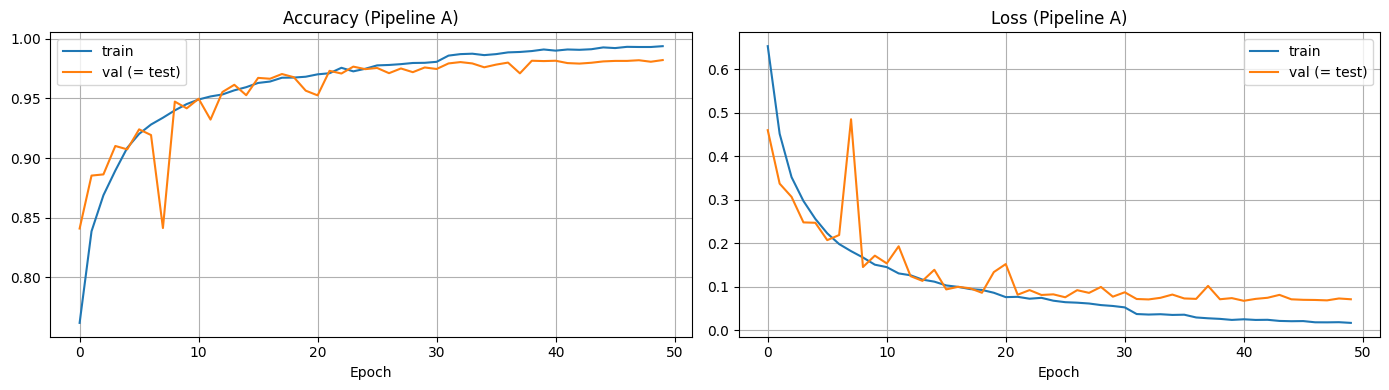

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# Pipeline A — Model 1 of 1: model_v2  (in-memory only, NEVER saved to disk)
#
# This is the ONLY model for Pipeline A. It is trained here from scratch on
# the flawed dataset (globally scaled, naive windows, 2-way split) and lives
# only in the kernel variable `model_v2`.  Pipeline B has its own completely
# separate models trained below (cell 16) — model_v2 is NEVER used there.
# ════════════════════════════════════════════════════════════════════════════
model_v2 = build_deepconv_lstm(
    window_size=V2_TIME_PERIODS,
    num_features=V2_N_FEATURES,
    num_classes=len(V2_LABELS),
    dropout=0.3,
)
model_v2 = compile_deepconv_lstm(model_v2)  # RMSprop lr=0.001, categorical_crossentropy

callbacks_v2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
]

# NOTE: x_test_v2 is passed directly as validation_data — the test set is used
# during training for early stopping and LR reduction (no separate val set).
history_v2 = model_v2.fit(
    x_train_v2,
    y_train_v2_oh,
    epochs=50,
    batch_size=64,
    validation_data=(x_test_v2, y_test_v2_oh),
    callbacks=callbacks_v2,
)

# ── Training curves ───────────────────────────────────────────────────────────

# ── Save Pipeline A model to disk ─────────────────────────────────────────────────────
# Saved for reproducibility / later inspection. File name clearly identifies
# this as the Pipeline A (flawed methodology) model.
model_v2_ckpt_path = (
    Path(cfg_effective["paths"]["checkpoints_dir"])
    / f"deepconv_lstm_pipelineA_T{V2_TIME_PERIODS}.keras"
)
model_v2_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
model_v2.save(model_v2_ckpt_path)
print(f"Pipeline A model saved: {model_v2_ckpt_path}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_v2.history["accuracy"], label="train")
axes[0].plot(history_v2.history["val_accuracy"], label="val (= test)")
axes[0].set_title("Accuracy (Pipeline A)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history_v2.history["loss"], label="train")
axes[1].plot(history_v2.history["val_loss"], label="val (= test)")

axes[1].set_title("Loss (Pipeline A)")

axes[1].set_xlabel("Epoch")

axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()


Test loss:     0.0714
Test accuracy: 0.9822   (target: 0.9824)
222/222 [==============================] - 4s 16ms/step
Precision: 0.9823  Recall: 0.9822  F1: 0.9822

Classification report (Pipeline A float):
              precision    recall  f1-score   support

  Downstairs       0.94      0.96      0.95       686
     Jogging       0.99      0.99      0.99      2156
     Sitting       0.98      0.99      0.99       377
    Standing       1.00      0.99      1.00       323
    Upstairs       0.95      0.94      0.94       811
     Walking       0.99      0.99      0.99      2733

    accuracy                           0.98      7086
   macro avg       0.98      0.98      0.98      7086
weighted avg       0.98      0.98      0.98      7086



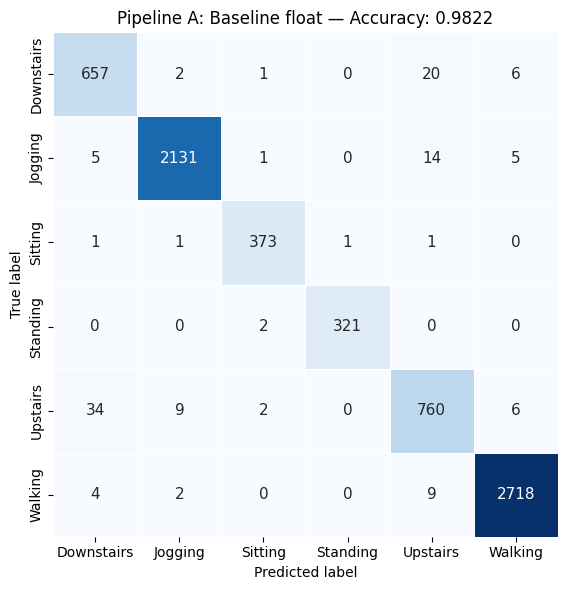

In [9]:
# ── Baseline (float) evaluation — Pipeline A ─────────────────────────────────
loss_v2, float_accuracy_v2 = model_v2.evaluate(x_test_v2, y_test_v2_oh, verbose=0)
print(f"Test loss:     {loss_v2:.4f}")
print(f"Test accuracy: {float_accuracy_v2:.4f}   (target: 0.9824)")

y_pred_v2_prob = model_v2.predict(x_test_v2)
y_pred_v2 = y_pred_v2_prob.argmax(axis=-1)
y_true_v2 = y_test_v2_oh.argmax(axis=-1)

precision_v2, recall_v2, f1_v2, _ = _prfs(y_true_v2, y_pred_v2, average="weighted")
print(f"Precision: {precision_v2:.4f}  Recall: {recall_v2:.4f}  F1: {f1_v2:.4f}")

print("\nClassification report (Pipeline A float):")
print(_cr(y_true_v2, y_pred_v2, target_names=V2_LABELS))

# Confusion matrix
cm_v2 = _cm(y_true_v2, y_pred_v2)
fig, ax = plt.subplots(figsize=(8, 6))
if sns is not None:
    sns.heatmap(
        pd.DataFrame(cm_v2, index=V2_LABELS, columns=V2_LABELS),
        annot=True, fmt="d", cmap="Blues", linewidths=0.5,
        cbar=False, annot_kws={"size": 11}, square=True, ax=ax,
    )
else:
    im = ax.imshow(cm_v2, cmap="Blues")
    plt.colorbar(im, ax=ax)
ax.set_title(f"Pipeline A: Baseline float — Accuracy: {float_accuracy_v2:.4f}")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Pipeline A — PTQ: quantizes model_v2 (the Pipeline A fp32 model only)
#
# Source model : `model_v2`  — trained exclusively in the previous cell.
# This is INDEPENDENT of Pipeline B's checkpoints.  Pipeline B PTQ (cell 18)
# loads its own saved `.keras` checkpoints and does NOT touch model_v2.
# ════════════════════════════════════════════════════════════════════════════
# Fix input shape to batch=1 for conversion.
model_v2.input.set_shape((1,) + tuple(model_v2.input.shape[1:]))

def _representative_dataset_v2():
    """100 samples from x_test — matches original authorcal approach."""
    for sample in tf.data.Dataset.from_tensor_slices(x_test_v2).batch(1).take(V2_REP_SAMPLES):
        yield [tf.cast(sample, tf.float32)]

converter_v2 = tf.lite.TFLiteConverter.from_keras_model(model_v2)
converter_v2.optimizations = [tf.lite.Optimize.DEFAULT]
converter_v2.representative_dataset = _representative_dataset_v2
converter_v2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_v2.inference_input_type = tf.int8
converter_v2.inference_output_type = tf.int8

tflite_v2 = converter_v2.convert()

tflite_path_v2 = Path(cfg_effective["paths"]["models_tflite_dir"]) / "deepconv_lstm_v2_ptq_int8.tflite"
tflite_path_v2.parent.mkdir(parents=True, exist_ok=True)
tflite_path_v2.write_bytes(tflite_v2)

model_size_v2_kb = tflite_path_v2.stat().st_size / 1024.0
print(f"PTQ int8 model saved : {tflite_path_v2}")
print(f"Model size           : {model_size_v2_kb:.2f} KB   (target: 136.51 KB)")

# ── Evaluate PTQ model ────────────────────────────────────────────────────────
interp_v2 = tf.lite.Interpreter(model_path=str(tflite_path_v2))
interp_v2.allocate_tensors()

input_det_v2 = interp_v2.get_input_details()[0]
output_det_v2 = interp_v2.get_output_details()[0]
in_scale_v2, in_zero_v2 = input_det_v2["quantization"]

print(f"Input  dtype : {input_det_v2['dtype']}")
print(f"Output dtype : {output_det_v2['dtype']}")

y_pred_ptq_v2, y_true_ptq_v2 = [], []
for i in range(len(x_test_v2)):
    q = np.round(x_test_v2[i : i + 1] / in_scale_v2 + in_zero_v2)
    q = np.clip(q, np.iinfo(np.int8).min, np.iinfo(np.int8).max).astype(np.int8)
    interp_v2.set_tensor(input_det_v2["index"], q)
    interp_v2.invoke()
    out = interp_v2.get_tensor(output_det_v2["index"])
    y_pred_ptq_v2.append(int(np.argmax(out)))
    y_true_ptq_v2.append(int(np.argmax(y_test_v2_oh[i])))

ptq_accuracy_v2 = accuracy_score(y_true_ptq_v2, y_pred_ptq_v2)
ptq_f1_v2 = f1_score(y_true_ptq_v2, y_pred_ptq_v2, average="macro")

print(f"\nPTQ int8 accuracy : {ptq_accuracy_v2:.4f}   (target: 0.9709)")

print(f"PTQ int8 macro-F1 : {ptq_f1_v2:.4f}")
print("\nClassification report (Pipeline A PTQ):")
print(_cr(y_true_ptq_v2, y_pred_ptq_v2, target_names=V2_LABELS))



INFO:tensorflow:Assets written to: /tmp/tmpedjlo64k/assets


INFO:tensorflow:Assets written to: /tmp/tmpedjlo64k/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-02 23:45:58.701468: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-02 23:45:58.701523: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-02 23:45:58.705238: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpedjlo64k
2026-03-02 23:45:58.708992: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-02 23:45:58.709017: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpedjlo64k
2026-03-02 23:45:58.721661: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 opt

PTQ int8 model saved : /home/dellio/github/har-mcu/models_tflite/deepconv_lstm_v2_ptq_int8.tflite
Model size           : 136.93 KB   (target: 136.51 KB)
Input  dtype : <class 'numpy.int8'>
Output dtype : <class 'numpy.int8'>


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



PTQ int8 accuracy : 0.9750   (target: 0.9709)
PTQ int8 macro-F1 : 0.9664

Classification report (Pipeline A PTQ):
              precision    recall  f1-score   support

  Downstairs       0.89      0.95      0.92       686
     Jogging       0.99      0.98      0.99      2156
     Sitting       0.99      0.99      0.99       377
    Standing       1.00      0.99      1.00       323
    Upstairs       0.93      0.89      0.91       811
     Walking       0.99      0.99      0.99      2733

    accuracy                           0.98      7086
   macro avg       0.97      0.97      0.97      7086
weighted avg       0.98      0.98      0.98      7086



In [11]:
# ── Pipeline A: Verdict table ─────────────────────────────────────────────────
_v2_checks = [
    {
        "check": "Baseline accuracy (target 0.9824, tol ±0.02)",
        "target": 0.9824,
        "achieved": round(float_accuracy_v2, 4),
        "delta": round(float_accuracy_v2 - 0.9824, 4),
        "status": "PASS" if abs(float_accuracy_v2 - 0.9824) <= 0.02 else "WARN",
    },
    {
        "check": "PTQ int8 accuracy (target 0.9709, tol ±0.03)",
        "target": 0.9709,
        "achieved": round(ptq_accuracy_v2, 4),
        "delta": round(ptq_accuracy_v2 - 0.9709, 4),
        "status": "PASS" if abs(ptq_accuracy_v2 - 0.9709) <= 0.03 else "WARN",
    },
    {
        "check": "PTQ model size KB (target 136.51, tol ±60)",
        "target": 136.51,
        "achieved": round(model_size_v2_kb, 2),
        "delta": round(model_size_v2_kb - 136.51, 2),
        "status": "PASS" if abs(model_size_v2_kb - 136.51) <= 60.0 else "WARN",
    },
]
display(pd.DataFrame(_v2_checks))


,check,target,achieved,delta,status
0,"Baseline accuracy (target 0.9824, tol ±0.02)",0.9824,0.9822,-0.0002,PASS
1,"PTQ int8 accuracy (target 0.9709, tol ±0.03)",0.9709,0.9750,0.0041,PASS
2,"PTQ model size KB (target 136.51, tol ±60)",136.5100,136.9300,0.4200,PASS


---

## Pipeline B — Safe Methodology (v1)

Correct pipeline with no data leakage, per-user-safe windowing, and a dedicated validation set.
Both split protocols (`random_stratified` and `user_holdout`) are evaluated.
PTQ uses the same direct int8 TFLite conversion approach as Pipeline A.
QAT is attempted but may fail due to a `tfmot`/`keras.src` Conv1D registry mismatch
(tracked as a TODO — see TODOlist.md).


### Key Concepts in Pipeline B

#### `drop_cross_boundary` — Window Label Policy
**What it means**: When sliding a window over sensor data, a window may start on one
activity (e.g., *Walking*) and end on another (e.g., *Jogging*). `drop_cross_boundary`
discards any window where the activity label is **not constant** across all timesteps,
so every kept window contains exactly one unambiguous activity.

**Why it matters**: Pipeline A uses `scipy.stats.mode` (majority vote), silently keeping
mixed-activity windows. This inflates accuracy because the model sees transition patterns
that leak label information.

**Where in the code**: `src/data/windowing.py` → `generate_windows()`.
Controlled by `cfg["label_policy"]` (`"drop_cross_boundary"` in `configs/default.yaml`).

---

#### `random_stratified` — Split Protocol
**What it means**: Windows are shuffled and split into train / val / test sets randomly,
while *stratifying* on the activity label so each split has roughly the same class
distribution. Windows from the same user can appear in **different** splits.

**Why it matters**: Standard ML evaluation. Generally produces higher accuracy than
`user_holdout` because the model sees examples from every user during training.

**Where in the code**: `src/data/splits.py` → `make_random_stratified_split()`.
Uses `sklearn.model_selection.train_test_split(..., stratify=y)` in two steps.

---

#### `user_holdout` — Split Protocol
**What it means**: Entire users are held out for validation and test. All windows from a
held-out user go **exclusively** into the test (or val) set — none of their data is seen
during training.

**Why it matters**: The harder, more realistic evaluation — measures whether the model
generalises to **new people**. Accuracy is typically lower than `random_stratified`
because activity patterns (e.g., personal gait style) vary between individuals unseen
at training time.

**Where in the code**: `src/data/splits.py` → `make_user_holdout_split()`.
Uses `sklearn.model_selection.GroupShuffleSplit(groups=users)` to guarantee no user
appears in both train and test.


In [12]:
dataset_cards = {}
split_rows = []
class_rows = []

for protocol in PROTOCOLS:
    out = build_dataset_for_protocol(cfg_effective, WINDOW_SIZE, protocol)
    card = load_json(out["artifacts"]["datacard"])
    dataset_cards[protocol] = card

    split_rows.append(
        {
            "protocol": protocol,
            "window_size": card["windowing"]["window_size"],
            "step": card["windowing"]["step"],
            "label_policy": card["windowing"].get("label_policy"),
            "candidate_windows": card["windowing"]["candidate_windows"],
            "windows_final": card["windowing"]["windows_final"],
            "train_size": card["split"]["train_size"],
            "val_size": card["split"]["val_size"],
            "test_size": card["split"]["test_size"],
            "split_hash": card["split"]["split_hash"],
        }
    )

    for cls, counts in card["counts"].items():
        class_rows.append(
            {
                "protocol": protocol,
                "activity": cls,
                "train": counts["train"],
                "val": counts["val"],
                "test": counts["test"],
            }
        )

split_df = pd.DataFrame(split_rows)
class_df = pd.DataFrame(class_rows)

# Methodology guardrails (must remain leakage-safe unlike v2 pitfalls).
if cfg_effective.get("label_policy") != EXPECTED_LABEL_POLICY:
    raise RuntimeError(
        f"Config label_policy is {cfg_effective.get('label_policy')}, expected {EXPECTED_LABEL_POLICY}"
    )

for protocol, card in dataset_cards.items():
    if card["split"]["val_size"] <= 0:
        raise RuntimeError(f"{protocol}: validation split missing")
    if card["split"]["test_size"] <= 0:
        raise RuntimeError(f"{protocol}: test split missing")

    # Optional datacard consistency check: some historical cards may omit this field.
    lp_card = card["windowing"].get("label_policy")
    if lp_card is not None and lp_card != EXPECTED_LABEL_POLICY:
        raise RuntimeError(
            f"{protocol}: datacard label_policy is {lp_card}, expected {EXPECTED_LABEL_POLICY}"
        )

    if not card["split"].get("split_hash"):
        raise RuntimeError(f"{protocol}: split_hash missing")

display(split_df)
display(class_df)

,protocol,window_size,step,label_policy,candidate_windows,windows_final,train_size,val_size,test_size,split_hash
0,random_stratified,100,50,None,21421,20709,11100,2775,6834,e8b3eefc294da8de
1,user_holdout,100,50,None,21421,20709,10945,2713,7051,8f23a2e13f210a67


,protocol,activity,train,val,test
0,random_stratified,Downstairs,954,238,587
1,random_stratified,Jogging,3425,856,2109
2,random_stratified,Sitting,619,155,381
3,random_stratified,Standing,493,123,304
4,random_stratified,Upstairs,1186,297,730
5,random_stratified,Walking,4423,1106,2723
6,user_holdout,Downstairs,896,250,633
7,user_holdout,Jogging,3159,939,2292
8,user_holdout,Sitting,816,70,269
9,user_holdout,Standing,606,46,268


Epoch 1/50
174/174 - 17s - loss: 0.7373 - accuracy: 0.7386 - val_loss: 0.8955 - val_accuracy: 0.6995 - lr: 0.0010 - 17s/epoch - 95ms/step
Epoch 2/50
174/174 - 15s - loss: 0.4858 - accuracy: 0.8211 - val_loss: 0.4065 - val_accuracy: 0.8425 - lr: 0.0010 - 15s/epoch - 86ms/step
Epoch 3/50
174/174 - 15s - loss: 0.4145 - accuracy: 0.8448 - val_loss: 0.3828 - val_accuracy: 0.8551 - lr: 0.0010 - 15s/epoch - 86ms/step
Epoch 4/50
174/174 - 15s - loss: 0.3410 - accuracy: 0.8727 - val_loss: 0.3703 - val_accuracy: 0.8609 - lr: 0.0010 - 15s/epoch - 87ms/step
Epoch 5/50
174/174 - 15s - loss: 0.2780 - accuracy: 0.8987 - val_loss: 0.2555 - val_accuracy: 0.9106 - lr: 0.0010 - 15s/epoch - 89ms/step
Epoch 6/50
174/174 - 15s - loss: 0.2318 - accuracy: 0.9156 - val_loss: 0.2618 - val_accuracy: 0.9056 - lr: 0.0010 - 15s/epoch - 86ms/step
Epoch 7/50
174/174 - 15s - loss: 0.1968 - accuracy: 0.9309 - val_loss: 0.1613 - val_accuracy: 0.9477 - lr: 0.0010 - 15s/epoch - 85ms/step
Epoch 8/50
174/174 - 15s - loss: 0

,checkpoint,history,epochs_ran,final_val_accuracy,reused_checkpoint,protocol
0,/home/dellio/github/har-mcu/checkpoints/deepco...,/home/dellio/github/har-mcu/checkpoints/histor...,46,0.986667,False,random_stratified
1,/home/dellio/github/har-mcu/checkpoints/deepco...,/home/dellio/github/har-mcu/checkpoints/histor...,12,0.625138,False,user_holdout



Pipeline B checkpoint paths (one per protocol, isolated from Pipeline A model_v2):
  [   random_stratified]  /home/dellio/github/har-mcu/checkpoints/deepconv_lstm_T100_Prandom_stratified.keras
  [        user_holdout]  /home/dellio/github/har-mcu/checkpoints/deepconv_lstm_T100_Puser_holdout.keras


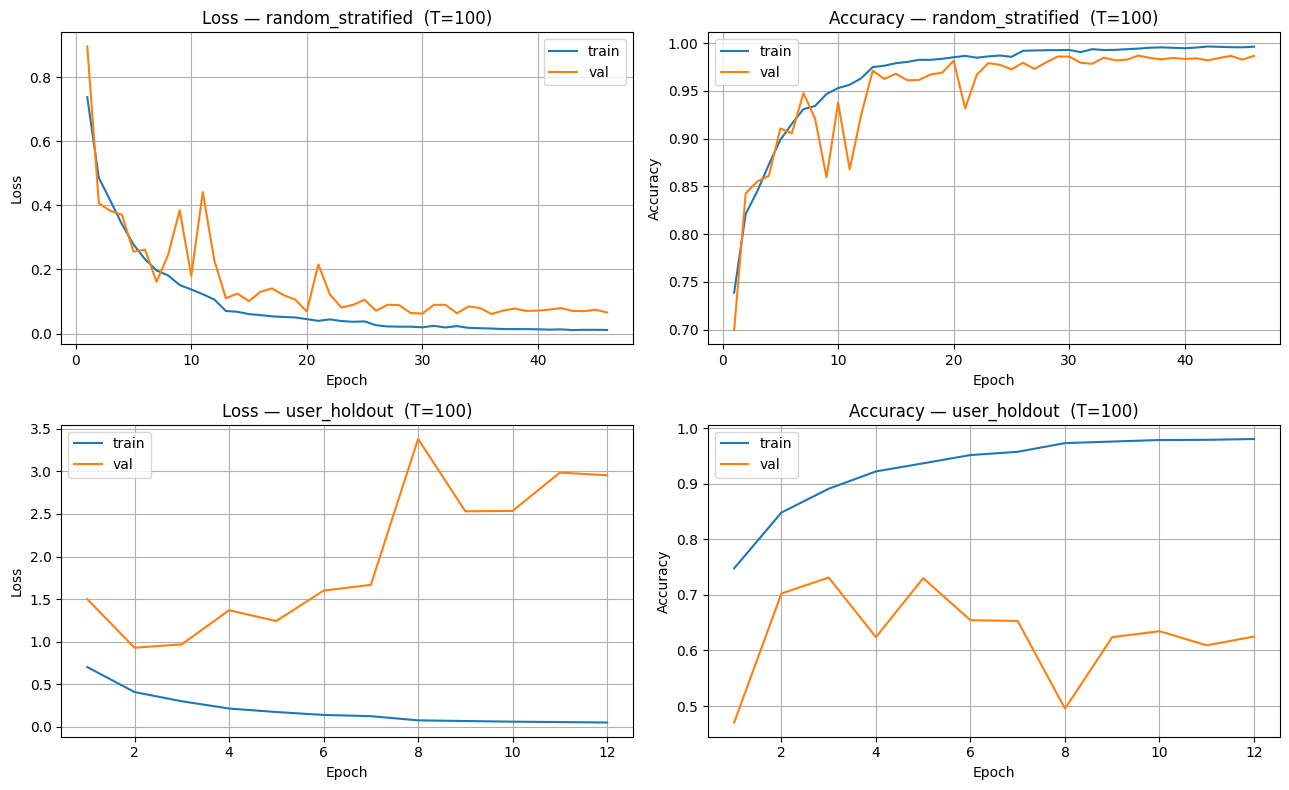

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# Pipeline B — Model training: one separate fp32 model per protocol
#
# Architecture controlled by PIPELINE_B_MODEL (set in the params cell):
#   "conv2d"  → build_deepconv_lstm_conv2d  ← default; QAT-compatible
#   "conv1d"  → build_deepconv_lstm         ← original Conv1D; QAT will fail
#
# Two completely independent models are trained here (or reloaded from disk
# if checkpoints already exist and FORCE_RETRAIN=False):
#   • deepconv_lstm_T{WINDOW_SIZE}_Prandom_stratified.keras
#   • deepconv_lstm_T{WINDOW_SIZE}_Puser_holdout.keras
#
# Neither model has any relation to Pipeline A's `model_v2` (which always
# uses Conv1D regardless of this setting).  Both checkpoints are saved to
# disk and reused by the PTQ and QAT sections below.
# ════════════════════════════════════════════════════════════════════════════
baseline_train_rows = []

for protocol in PROTOCOLS:
    ckpt_path = baseline_ckpt_path(cfg_effective["paths"]["checkpoints_dir"], WINDOW_SIZE, protocol)
    hist_path = history_path(cfg_effective["paths"]["checkpoints_dir"], WINDOW_SIZE, protocol)

    if ckpt_path.exists() and not FORCE_RETRAIN:
        train_out = {
            "checkpoint": str(ckpt_path),
            "history": str(hist_path) if hist_path.exists() else None,
            "epochs_ran": 0,
            "final_val_accuracy": None,
            "reused_checkpoint": True,
        }
    else:
        train_out = train_baseline_for_protocol(
            cfg_effective, WINDOW_SIZE, protocol,
            model_builder=_pipeline_b_builder,  # None → default Conv1D
        )
        train_out["reused_checkpoint"] = False

    train_out["protocol"] = protocol
    baseline_train_rows.append(train_out)

baseline_train_df = pd.DataFrame(baseline_train_rows)
display(baseline_train_df)

# ── Checkpoint isolation verification ────────────────────────────────────────
# Each protocol produces a unique checkpoint file.  Neither path overlaps
# with Pipeline A's deepconv_lstm_pipelineA_T{V2_TIME_PERIODS}.keras.
print("\nPipeline B checkpoint paths (one per protocol, isolated from Pipeline A model_v2):")
for row in baseline_train_rows:
    print(f"  [{row['protocol']:>20s}]  {row['checkpoint']}")

# ── Per-protocol training curves ─────────────────────────────────────────────
_hist_to_plot = []
for row in baseline_train_rows:
    hp = row.get("history")
    if hp and Path(hp).exists():
        _hist_to_plot.append((row["protocol"], load_json(hp)))

if _hist_to_plot:
    n_proto = len(_hist_to_plot)
    fig, axes = plt.subplots(n_proto, 2, figsize=(13, 4 * n_proto), squeeze=False)
    for ax_row, (proto, hist) in zip(axes, _hist_to_plot):
        epochs = range(1, len(hist["loss"]) + 1)
        ax_row[0].plot(epochs, hist["loss"], label="train")
        ax_row[0].plot(epochs, hist.get("val_loss", []), label="val")
        ax_row[0].set_title(f"Loss — {proto}  (T={WINDOW_SIZE})")
        ax_row[0].set_xlabel("Epoch")
        ax_row[0].set_ylabel("Loss")
        ax_row[0].legend()
        ax_row[0].grid(True)
        acc_key = "accuracy" if "accuracy" in hist else "acc"
        val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"
        ax_row[1].plot(epochs, hist.get(acc_key, []), label="train")
        ax_row[1].plot(epochs, hist.get(val_acc_key, []), label="val")
        ax_row[1].set_title(f"Accuracy — {proto}  (T={WINDOW_SIZE})")
        ax_row[1].set_xlabel("Epoch")
        ax_row[1].set_ylabel("Accuracy")
        ax_row[1].legend()
        ax_row[1].grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("(No history JSON files available — training curves skipped. Re-run with FORCE_RETRAIN=True to regenerate.)")


,protocol,accuracy,macro_f1,confusion_plot,metrics_json,report_md
0,random_stratified,0.988147,0.982913,/home/dellio/github/har-mcu/reports/confusion_...,/home/dellio/github/har-mcu/reports/baseline_T...,/home/dellio/github/har-mcu/reports/baseline_T...
1,user_holdout,0.716494,0.589594,/home/dellio/github/har-mcu/reports/confusion_...,/home/dellio/github/har-mcu/reports/baseline_T...,/home/dellio/github/har-mcu/reports/baseline_T...



══════════════════════════════════════════════════════════════
  Baseline — random_stratified  |  Acc: 0.9881  |  Macro-F1: 0.9829
══════════════════════════════════════════════════════════════

                        precision     recall   f1-score  support
                       ---------- ---------- ---------- --------
               Walking     0.9963     0.9934     0.9949     2723
               Jogging     0.9962     0.9948     0.9955     2109
              Upstairs     0.9565     0.9630     0.9597      730
            Downstairs     0.9624     0.9591     0.9608      587
               Sitting     0.9794     0.9974     0.9883      381
              Standing     0.9967     1.0000     0.9984      304

             macro avg     0.9812     0.9846     0.9829     6834
          weighted avg     0.9882     0.9881     0.9882     6834


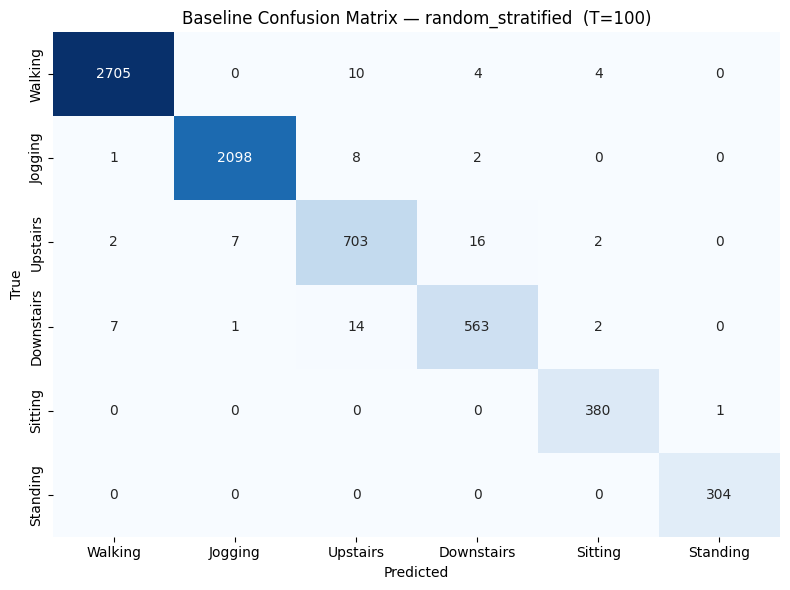


══════════════════════════════════════════════════════════════
  Baseline — user_holdout  |  Acc: 0.7165  |  Macro-F1: 0.5896
══════════════════════════════════════════════════════════════

                        precision     recall   f1-score  support
                       ---------- ---------- ---------- --------
               Walking     0.8726     0.8442     0.8582     2702
               Jogging     0.9713     0.8425     0.9023     2292
              Upstairs     0.3030     0.2886     0.2956      887
            Downstairs     0.3543     0.1422     0.2029      633
               Sitting     0.9385     0.8513     0.8928      269
              Standing     0.2396     0.9888     0.3857      268

             macro avg     0.6132     0.6596     0.5896     7051
          weighted avg     0.7650     0.7165     0.7263     7051


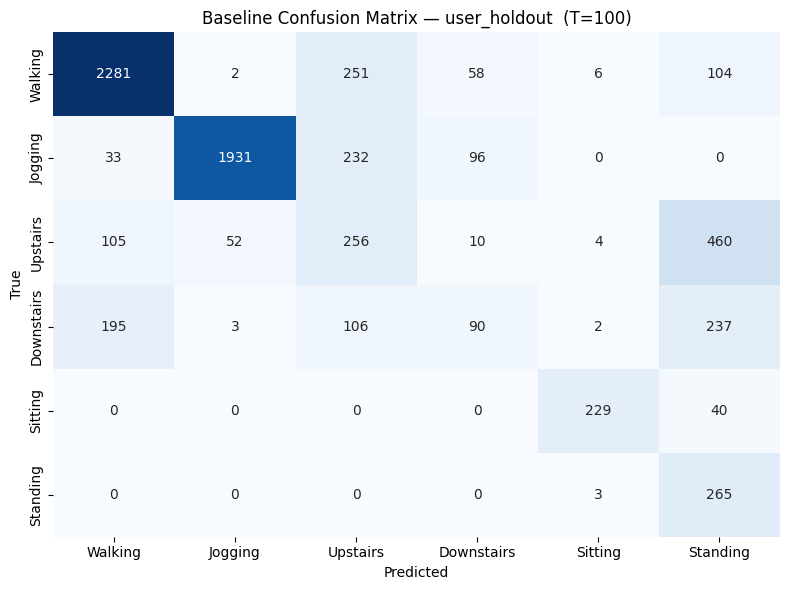

In [14]:
baseline_eval_metrics = {}
baseline_eval_rows = []

for protocol in PROTOCOLS:
    out = evaluate_baseline_for_protocol(cfg_effective, WINDOW_SIZE, protocol)
    m = load_json(out["metrics_json"])
    baseline_eval_metrics[protocol] = m

    baseline_eval_rows.append(
        {
            "protocol": protocol,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "confusion_plot": m["confusion_plot"],
            "metrics_json": out["metrics_json"],
            "report_md": out["report_md"],
        }
    )

baseline_eval_df = pd.DataFrame(baseline_eval_rows)
display(baseline_eval_df)

# ── Per-protocol classification reports and confusion matrices ────────────────
_class_names = cfg_effective.get("classes", [])
for protocol, m in baseline_eval_metrics.items():
    print(f"\n{'═' * 62}")
    print(f"  Baseline — {protocol}  |  Acc: {m['accuracy']:.4f}  |  Macro-F1: {m['macro_f1']:.4f}")
    print(f"{'═' * 62}")
    cr = m.get("classification_report", {})
    if cr and _class_names:
        print(f"\n  {'':20s} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>8}")
        print(f"  {'':20s} {'-'*10} {'-'*10} {'-'*10} {'-'*8}")
        for cls in _class_names:
            if cls in cr:
                r = cr[cls]
                print(f"  {cls:>20s} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>8}")
        print()
        for agg in ("macro avg", "weighted avg"):
            if agg in cr:
                r = cr[agg]
                print(f"  {agg:>20s} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>8}")
    cm_data = m.get("confusion_matrix")
    if cm_data is not None:
        fig, ax = plt.subplots(figsize=(8, 6))
        if sns is not None:
            sns.heatmap(
                np.array(cm_data), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=_class_names or "auto", yticklabels=_class_names or "auto", ax=ax,
            )
        else:
            im = ax.imshow(np.array(cm_data), cmap="Blues")
            plt.colorbar(im, ax=ax)
        ax.set_title(f"Baseline Confusion Matrix — {protocol}  (T={WINDOW_SIZE})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        plt.tight_layout()
        plt.show()


INFO:tensorflow:Assets written to: /tmp/tmpdq53pb8e/assets


INFO:tensorflow:Assets written to: /tmp/tmpdq53pb8e/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:01:03.812651: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:01:03.812696: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 00:01:03.814876: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpdq53pb8e
2026-03-03 00:01:03.819335: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:01:03.819349: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpdq53pb8e
2026-03-03 00:01:03.837001: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

INFO:tensorflow:Assets written to: /tmp/tmpyv8jm2kz/assets


INFO:tensorflow:Assets written to: /tmp/tmpyv8jm2kz/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:01:24.804852: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:01:24.804909: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 00:01:24.807227: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpyv8jm2kz
2026-03-03 00:01:24.813606: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:01:24.813646: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpyv8jm2kz
2026-03-03 00:01:24.836297: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

,protocol,variant,representative_source,representative_samples,replication_metrics_status,strict_deploy_status,accuracy,macro_f1,model_size_kb,input_dtype,output_dtype,deployable_full_int8,status,failure_reason,tflite_model
0,random_stratified,authorcal,test,100,ok,PASS,0.979222,0.970093,136.921875,<class 'numpy.int8'>,<class 'numpy.int8'>,True,ok,None,/home/dellio/github/har-mcu/models_tflite/deep...
1,user_holdout,authorcal,test,100,ok,PASS,0.644731,0.371483,136.921875,<class 'numpy.int8'>,<class 'numpy.int8'>,True,ok,None,/home/dellio/github/har-mcu/models_tflite/deep...



══════════════════════════════════════════════════════════════
  PTQ int8 — random_stratified  |  Acc: 0.9792  |  Macro-F1: 0.9701
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Walking       0.99      0.98      0.99      2723
     Jogging       1.00      0.99      0.99      2109
    Upstairs       0.89      0.96      0.93       730
  Downstairs       0.97      0.92      0.94       587
     Sitting       0.98      0.99      0.99       381
    Standing       0.98      0.98      0.98       304

    accuracy                           0.98      6834
   macro avg       0.97      0.97      0.97      6834
weighted avg       0.98      0.98      0.98      6834



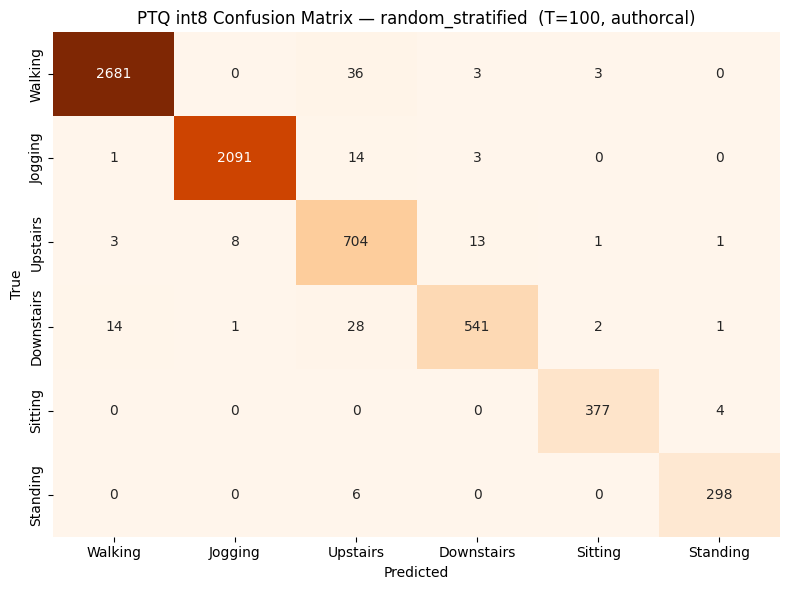


══════════════════════════════════════════════════════════════
  PTQ int8 — user_holdout  |  Acc: 0.6447  |  Macro-F1: 0.3715
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Walking       0.88      0.84      0.86      2702
     Jogging       0.97      0.85      0.90      2292
    Upstairs       0.20      0.25      0.22       887
  Downstairs       0.29      0.15      0.20       633
     Sitting       0.01      0.01      0.01       269
    Standing       0.03      0.07      0.04       268

    accuracy                           0.64      7051
   macro avg       0.39      0.36      0.37      7051
weighted avg       0.70      0.64      0.67      7051



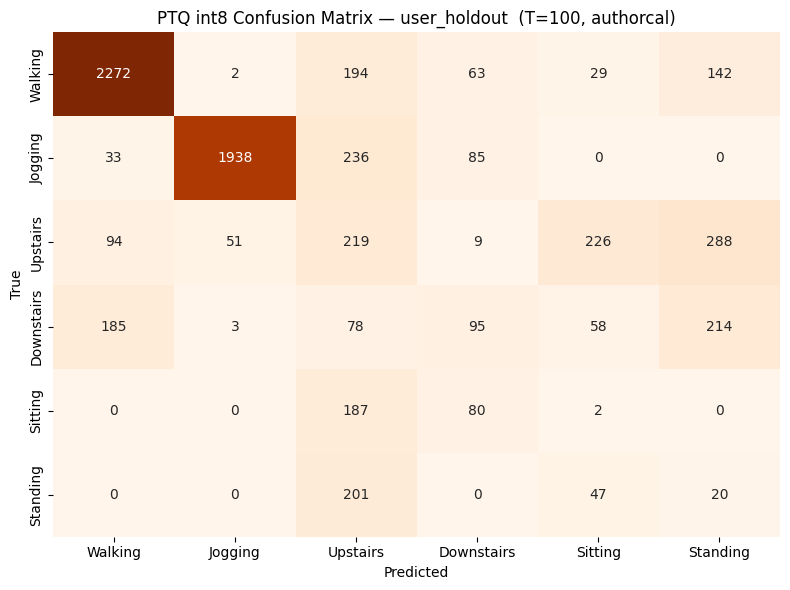

In [15]:
# ════════════════════════════════════════════════════════════════════════════
# Pipeline B — PTQ: quantizes each Pipeline B fp32 checkpoint independently
#
# For each protocol the corresponding Pipeline B checkpoint is loaded fresh:
#   • deepconv_lstm_T{WINDOW_SIZE}_Prandom_stratified.keras  → PTQ model A
#   • deepconv_lstm_T{WINDOW_SIZE}_Puser_holdout.keras        → PTQ model B
#
# Pipeline A's `model_v2` is NOT involved here in any way.
# ════════════════════════════════════════════════════════════════════════════
ptq_export_metrics = {}
ptq_eval_metrics = {}
ptq_rows = []

def evaluate_int8_tflite_model(model_path, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_det = interpreter.get_input_details()[0]
    output_det = interpreter.get_output_details()[0]

    in_scale, in_zero = input_det["quantization"]
    in_dtype = input_det["dtype"]

    if in_scale == 0:
        raise RuntimeError("Input tensor is not quantized; expected int8/uint8 model input")

    dtype_info = np.iinfo(in_dtype)
    y_pred = []
    y_true = []

    for i in range(len(X_test)):
        x = X_test[i:i+1]
        x_q = np.round(x / in_scale + in_zero)
        x_q = np.clip(x_q, dtype_info.min, dtype_info.max).astype(in_dtype)

        interpreter.set_tensor(input_det["index"], x_q)
        interpreter.invoke()
        out = interpreter.get_tensor(output_det["index"])

        y_pred.append(int(np.argmax(out, axis=-1)[0]))
        y_true.append(int(y_test[i]))

    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "model_size_kb": float(Path(model_path).stat().st_size / 1024.0),
        "input_dtype": str(input_det["dtype"]),
        "output_dtype": str(output_det["dtype"]),
        "y_true": y_true,
        "y_pred": y_pred,
    }

def convert_to_int8_tflite(model, X_test, out_path, rep_samples):
    model.input.set_shape((1,) + tuple(model.input.shape[1:]))
    rep_count = int(min(rep_samples, len(X_test)))

    def representative_dataset_gen():
        for sample in tf.data.Dataset.from_tensor_slices(X_test).batch(1).take(rep_count):
            yield [tf.cast(sample, tf.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_bytes(converter.convert())
    return rep_count

def write_quant_report_md(path, title, export_json):
    with path.open("w", encoding="utf-8") as f:
        f.write(f"# {title}\n\n")
        f.write(f"- status: `{export_json['status']}`\n")
        f.write(f"- representative_source: `test`\n")
        f.write(f"- representative_samples: `{export_json['representative_samples']}`\n")
        if export_json.get("tflite_model"):
            f.write(f"- tflite_model: `{export_json['tflite_model']}`\n")
        if export_json.get("model_size_kb") is not None:
            f.write(f"- model_size_kb: {export_json['model_size_kb']:.2f}\n")
        if export_json.get("qat_device_attempted"):
            f.write(f"- qat_device_attempted: `{export_json['qat_device_attempted']}`\n")
        if export_json.get("qat_device_used"):
            f.write(f"- qat_device_used: `{export_json['qat_device_used']}`\n")
        if export_json.get("fallback_triggered") is not None:
            f.write(f"- fallback_triggered: `{export_json['fallback_triggered']}`\n")
        if export_json.get("fallback_reason"):
            f.write(f"- fallback_reason: `{export_json['fallback_reason']}`\n")
        if export_json.get("error"):
            f.write(f"- error: `{export_json['error']}`\n")

for protocol in PROTOCOLS:
    arrays = load_split_arrays(cfg_effective["paths"]["processed_dir"], WINDOW_SIZE, protocol)
    X_test = arrays["X_test"]
    y_test = arrays["y_test"]

    ckpt_path = baseline_ckpt_path(cfg_effective["paths"]["checkpoints_dir"], WINDOW_SIZE, protocol)
    model = tf.keras.models.load_model(ckpt_path)

    tflite_path = Path(cfg_effective["paths"]["models_tflite_dir"]) / (
        f"deepconv_lstm_T{WINDOW_SIZE}_P{protocol}_ptq_int8_{CALIBRATION_VARIANT}.tflite"
    )
    report_json_path = Path(cfg_effective["paths"]["reports_dir"]) / (
        f"ptq_export_T{WINDOW_SIZE}_P{protocol}_{CALIBRATION_VARIANT}.json"
    )
    report_md_path = Path(cfg_effective["paths"]["reports_dir"]) / (
        f"ptq_export_T{WINDOW_SIZE}_P{protocol}_{CALIBRATION_VARIANT}.md"
    )

    export_json = {
        "window_size": int(WINDOW_SIZE),
        "protocol": protocol,
        "variant": CALIBRATION_VARIANT,
        "representative_samples": None,
        "tflite_model": None,
        "status": "error",
        "error": None,
    }
    eval_json = None

    try:
        rep_count = convert_to_int8_tflite(
            model=model,
            X_test=X_test,
            out_path=tflite_path,
            rep_samples=AUTHOR_STYLE_REP_SAMPLES,
        )
        eval_json = evaluate_int8_tflite_model(tflite_path, X_test, y_test)
        deployable_int8 = ("int8" in eval_json["input_dtype"].lower()) and ("int8" in eval_json["output_dtype"].lower())

        export_json.update(
            {
                "representative_samples": rep_count,
                "tflite_model": str(tflite_path),
                "model_size_kb": float(tflite_path.stat().st_size / 1024.0),
                "input_dtype": eval_json["input_dtype"],
                "output_dtype": eval_json["output_dtype"],
                "deployable_full_int8": bool(deployable_int8),
                "status": "ok",
                "error": None,
            }
        )
    except Exception as exc:
        export_json["error"] = str(exc)
        export_json["representative_samples"] = int(min(AUTHOR_STYLE_REP_SAMPLES, len(X_test)))
        if FAIL_FAST:
            raise

    dump_json(report_json_path, export_json)
    write_quant_report_md(
        report_md_path,
        f"PTQ Export (T={WINDOW_SIZE}, protocol={protocol}, variant={CALIBRATION_VARIANT})",
        export_json,
    )

    ptq_export_metrics[protocol] = export_json
    if eval_json is not None:
        ptq_eval_metrics[protocol] = eval_json

    ptq_rows.append(
        {
            "protocol": protocol,
            "variant": CALIBRATION_VARIANT,
            "representative_source": "test",
            "representative_samples": export_json.get("representative_samples"),
            "replication_metrics_status": "ok" if eval_json is not None else "error",
            "strict_deploy_status": "PASS" if export_json.get("deployable_full_int8") else "FAIL",
            "accuracy": eval_json.get("accuracy") if eval_json else None,
            "macro_f1": eval_json.get("macro_f1") if eval_json else None,
            "model_size_kb": eval_json.get("model_size_kb") if eval_json else export_json.get("model_size_kb"),
            "input_dtype": export_json.get("input_dtype"),
            "output_dtype": export_json.get("output_dtype"),
            "deployable_full_int8": export_json.get("deployable_full_int8", False),
            "status": export_json.get("status"),
            "failure_reason": export_json.get("error"),
            "tflite_model": export_json.get("tflite_model"),
        }
    )

ptq_df = pd.DataFrame(ptq_rows)
display(ptq_df)

# ── Per-protocol PTQ classification reports and confusion matrices ─────────────
_class_names = cfg_effective.get("classes", [])
for protocol, ev in ptq_eval_metrics.items():
    print(f"\n{'═' * 62}")
    print(f"  PTQ int8 — {protocol}  |  Acc: {ev['accuracy']:.4f}  |  Macro-F1: {ev['macro_f1']:.4f}")
    print(f"{'═' * 62}")
    _yt = ev.get("y_true", [])
    _yp = ev.get("y_pred", [])
    if _yt and _yp and _class_names:
        print(_cr(_yt, _yp, target_names=_class_names, zero_division=0))
        cm = _cm(_yt, _yp)
        fig, ax = plt.subplots(figsize=(8, 6))
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                        xticklabels=_class_names, yticklabels=_class_names, ax=ax)
        else:
            im = ax.imshow(cm, cmap="Oranges")
            plt.colorbar(im, ax=ax)
        ax.set_title(f"PTQ int8 Confusion Matrix — {protocol}  (T={WINDOW_SIZE}, {CALIBRATION_VARIANT})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        plt.tight_layout()
        plt.show()


### QAT Runtime Notes (why this output can look confusing)

- `Epoch 1/10` can appear twice because this section trains two independent models: one for `random_stratified` and one for `user_holdout`.
- `layout failed ... SelectV2-TransposeNHWCToNCHW-LayoutOptimizer` is a Grappler layout-optimization warning around Dropout/`SelectV2`. In this notebook it is treated as non-fatal and training can continue.
- The fatal QAT blocker in this repo is different: deterministic GPU training can fail at `FakeQuantWithMinMaxVarsGradient`.
- GPU failure + CPU retry has already been observed in this project. For stable reruns now, this notebook is configured for CPU (`USE_GPU=False`, `QAT_DEVICE_PREFERENCE="cpu"`).


Epoch 1/10
174/174 - 17s - loss: 0.0307 - accuracy: 0.9844 - val_loss: 0.0690 - val_accuracy: 0.9831 - 17s/epoch - 97ms/step
Epoch 2/10
174/174 - 15s - loss: 0.0145 - accuracy: 0.9961 - val_loss: 0.0673 - val_accuracy: 0.9838 - 15s/epoch - 88ms/step
Epoch 3/10
174/174 - 15s - loss: 0.0133 - accuracy: 0.9960 - val_loss: 0.0724 - val_accuracy: 0.9841 - 15s/epoch - 86ms/step
Epoch 4/10
174/174 - 15s - loss: 0.0121 - accuracy: 0.9959 - val_loss: 0.0737 - val_accuracy: 0.9834 - 15s/epoch - 86ms/step
Epoch 5/10
174/174 - 15s - loss: 0.0134 - accuracy: 0.9961 - val_loss: 0.0735 - val_accuracy: 0.9827 - 15s/epoch - 87ms/step
Epoch 6/10
174/174 - 15s - loss: 0.0110 - accuracy: 0.9964 - val_loss: 0.0738 - val_accuracy: 0.9831 - 15s/epoch - 86ms/step
Epoch 7/10
174/174 - 15s - loss: 0.0109 - accuracy: 0.9968 - val_loss: 0.0722 - val_accuracy: 0.9841 - 15s/epoch - 86ms/step
Epoch 8/10
174/174 - 15s - loss: 0.0085 - accuracy: 0.9971 - val_loss: 0.0755 - val_accuracy: 0.9820 - 15s/epoch - 88ms/step


INFO:tensorflow:Assets written to: /tmp/tmp3snsi655/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:04:21.906108: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:04:21.906161: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 00:04:21.908823: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3snsi655
2026-03-03 00:04:21.918168: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:04:21.918196: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp3snsi655
2026-03-03 00:04:21.949309: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

Epoch 1/10
172/172 - 16s - loss: 0.2391 - accuracy: 0.9180 - val_loss: 1.2869 - val_accuracy: 0.6008 - 16s/epoch - 95ms/step
Epoch 2/10
172/172 - 15s - loss: 0.1918 - accuracy: 0.9375 - val_loss: 1.3701 - val_accuracy: 0.6156 - 15s/epoch - 86ms/step
Epoch 3/10
172/172 - 15s - loss: 0.1926 - accuracy: 0.9322 - val_loss: 1.4632 - val_accuracy: 0.6296 - 15s/epoch - 87ms/step
Epoch 4/10
172/172 - 15s - loss: 0.1756 - accuracy: 0.9371 - val_loss: 1.5844 - val_accuracy: 0.6251 - 15s/epoch - 87ms/step
Epoch 5/10
172/172 - 15s - loss: 0.1710 - accuracy: 0.9390 - val_loss: 1.4969 - val_accuracy: 0.6498 - 15s/epoch - 88ms/step
Epoch 6/10
172/172 - 15s - loss: 0.1545 - accuracy: 0.9456 - val_loss: 1.7275 - val_accuracy: 0.6104 - 15s/epoch - 88ms/step
Epoch 7/10
172/172 - 16s - loss: 0.1485 - accuracy: 0.9487 - val_loss: 1.8826 - val_accuracy: 0.6041 - 16s/epoch - 90ms/step
Epoch 8/10
172/172 - 15s - loss: 0.1384 - accuracy: 0.9529 - val_loss: 2.5294 - val_accuracy: 0.5090 - 15s/epoch - 87ms/step


INFO:tensorflow:Assets written to: /tmp/tmp4x0nbszs/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-03 00:07:16.638417: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 00:07:16.638488: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 00:07:16.643129: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4x0nbszs
2026-03-03 00:07:16.651000: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 00:07:16.651019: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp4x0nbszs
2026-03-03 00:07:16.675754: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

,protocol,variant,representative_source,representative_samples,replication_metrics_status,strict_deploy_status,accuracy,macro_f1,model_size_kb,input_dtype,output_dtype,deployable_full_int8,status,failure_reason,qat_device_attempted,qat_device_used,fallback_triggered,fallback_reason,tflite_model
0,random_stratified,authorcal,test,100,ok,PASS,0.534680,0.521391,137.34375,<class 'numpy.int8'>,<class 'numpy.int8'>,True,ok,None,[/CPU:0],/CPU:0,False,None,/home/dellio/github/har-mcu/models_tflite/deep...
1,user_holdout,authorcal,test,100,ok,PASS,0.110197,0.105824,137.34375,<class 'numpy.int8'>,<class 'numpy.int8'>,True,ok,None,[/CPU:0],/CPU:0,False,None,/home/dellio/github/har-mcu/models_tflite/deep...


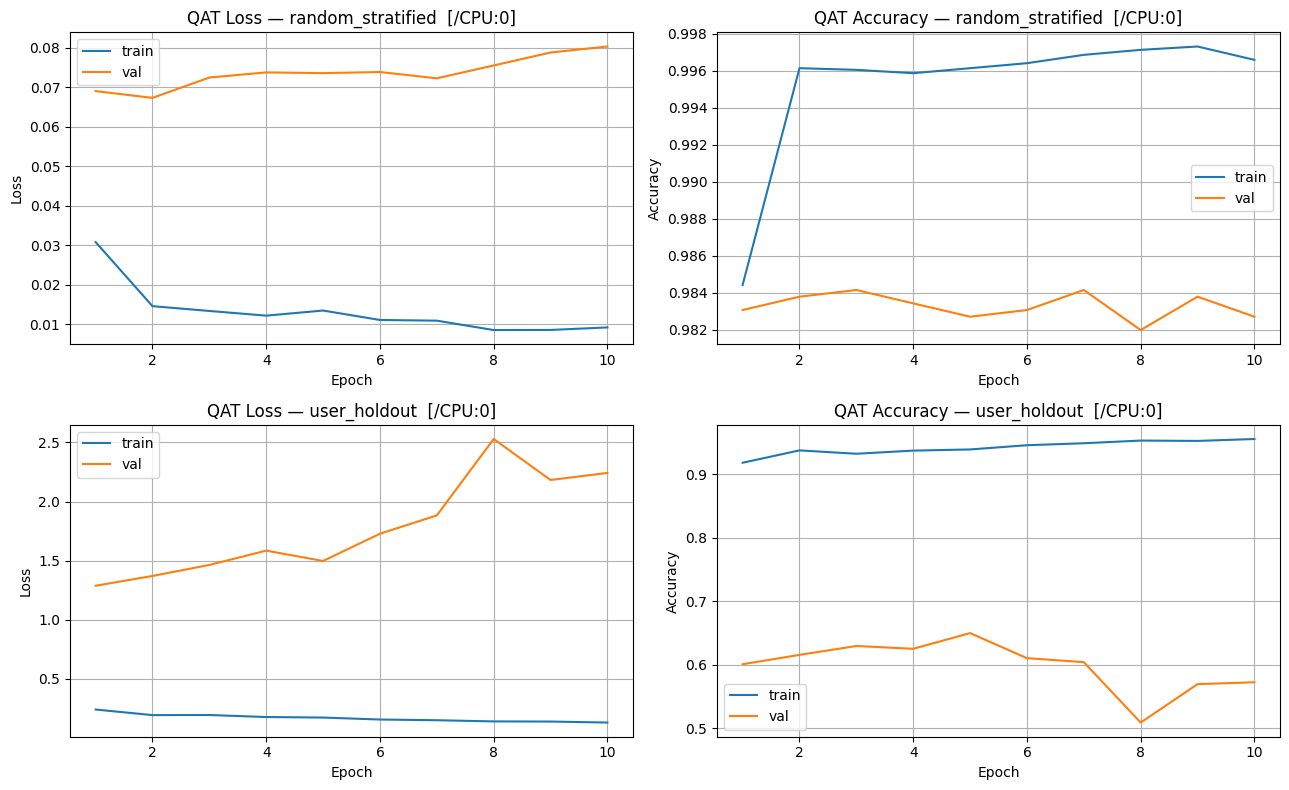


══════════════════════════════════════════════════════════════
  QAT int8 — random_stratified  |  Acc: 0.5347  |  Macro-F1: 0.5214
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Walking       0.86      0.57      0.68      2723
     Jogging       0.91      0.43      0.59      2109
    Upstairs       0.24      0.47      0.32       730
  Downstairs       0.19      0.51      0.28       587
     Sitting       0.67      0.97      0.79       381
    Standing       0.39      0.62      0.47       304

    accuracy                           0.53      6834
   macro avg       0.54      0.59      0.52      6834
weighted avg       0.72      0.53      0.58      6834



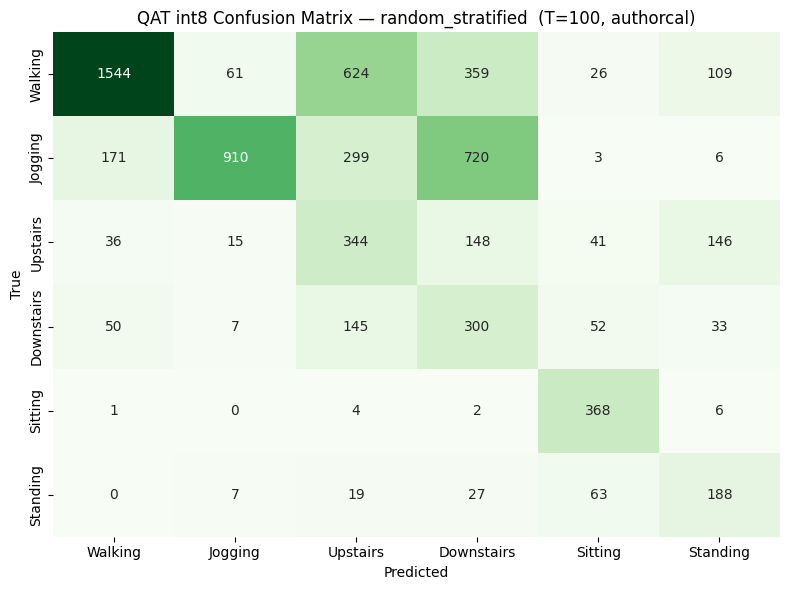


══════════════════════════════════════════════════════════════
  QAT int8 — user_holdout  |  Acc: 0.1102  |  Macro-F1: 0.1058
══════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

     Walking       0.00      0.00      0.00      2702
     Jogging       1.00      0.00      0.00      2292
    Upstairs       0.19      0.06      0.09       887
  Downstairs       0.10      0.98      0.18       633
     Sitting       0.35      0.36      0.36       269
    Standing       0.00      0.00      0.00       268

    accuracy                           0.11      7051
   macro avg       0.27      0.24      0.11      7051
weighted avg       0.37      0.11      0.04      7051



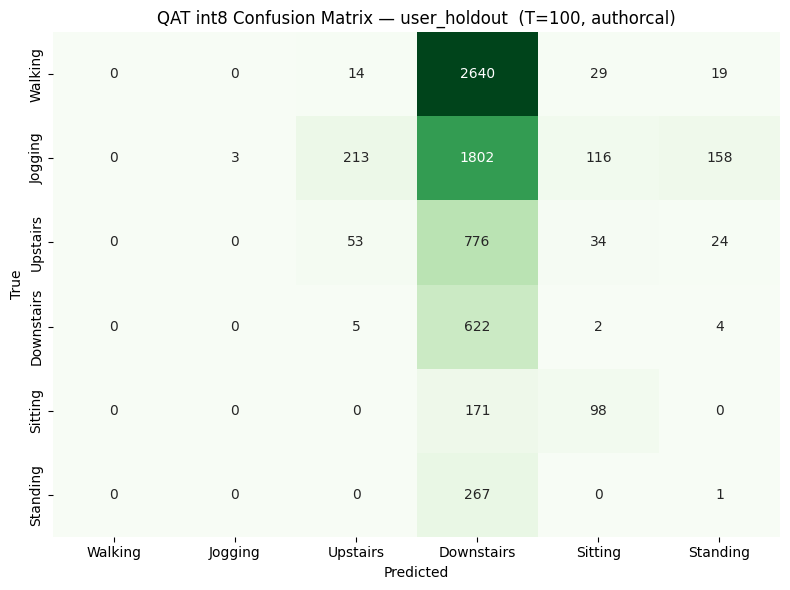

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# Pipeline B — QAT: fine-tunes each Pipeline B fp32 checkpoint with fake
#               quantization, then converts to int8 TFLite
#
# Starting point: the SAME Pipeline B checkpoints used by PTQ above.
#   • deepconv_lstm_T{WINDOW_SIZE}_Prandom_stratified.keras  → QAT model A
#   • deepconv_lstm_T{WINDOW_SIZE}_Puser_holdout.keras        → QAT model B
#
# Pipeline A's `model_v2` is NOT involved here.
# ════════════════════════════════════════════════════════════════════════════
qat_export_metrics = {}
qat_eval_metrics = {}
qat_rows = []
qat_history_metrics = {}


def _short_err(exc, max_len=220):
    msg = " ".join(str(exc).split())
    return msg if len(msg) <= max_len else (msg[: max_len - 3] + "...")


def _is_qat_gpu_determinism_error(exc):
    msg = str(exc)
    return (
        "FakeQuantWithMinMaxVarsGradient" in msg
        and "Determinism" in msg
    )


def _qat_device_order(preference, has_gpu, auto_fallback):
    pref = str(preference).strip().lower()
    if pref not in {"gpu", "cpu"}:
        raise ValueError(f"QAT_DEVICE_PREFERENCE must be 'gpu' or 'cpu', got: {preference}")

    if pref == "cpu" or not has_gpu:
        return ["/CPU:0"]

    order = ["/GPU:0"]
    if auto_fallback:
        order.append("/CPU:0")
    return order


if RUN_QAT:
    import tensorflow_model_optimization as tfmot

    has_gpu = bool(tf.config.list_physical_devices("GPU"))
    device_order = _qat_device_order(
        QAT_DEVICE_PREFERENCE,
        has_gpu=has_gpu,
        auto_fallback=bool(QAT_AUTO_FALLBACK_TO_CPU),
    )

    for protocol in PROTOCOLS:
        arrays = load_split_arrays(cfg_effective["paths"]["processed_dir"], WINDOW_SIZE, protocol)
        X_train, y_train = arrays["X_train"], arrays["y_train"]
        X_val, y_val = arrays["X_val"], arrays["y_val"]
        X_test, y_test = arrays["X_test"], arrays["y_test"]

        tflite_path = Path(cfg_effective["paths"]["models_tflite_dir"]) / (
            f"deepconv_lstm_T{WINDOW_SIZE}_P{protocol}_qat_{CALIBRATION_VARIANT}.tflite"
        )
        report_json_path = Path(cfg_effective["paths"]["reports_dir"]) / (
            f"qat_export_T{WINDOW_SIZE}_P{protocol}_{CALIBRATION_VARIANT}.json"
        )
        report_md_path = Path(cfg_effective["paths"]["reports_dir"]) / (
            f"qat_export_T{WINDOW_SIZE}_P{protocol}_{CALIBRATION_VARIANT}.md"
        )

        export_json = {
            "window_size": int(WINDOW_SIZE),
            "protocol": protocol,
            "variant": CALIBRATION_VARIANT,
            "epochs_ran": 0,
            "representative_samples": int(min(AUTHOR_STYLE_REP_SAMPLES, len(X_test))),
            "tflite_model": None,
            "status": "error",
            "error": None,
            "qat_device_attempted": [],
            "qat_device_used": None,
            "fallback_triggered": False,
            "fallback_reason": None,
        }
        eval_json = None

        qat_device_attempted = []
        qat_device_used = None
        fallback_triggered = False
        fallback_reason = None

        try:
            num_classes = len(cfg_effective.get("classes", [])) or int(np.max(y_train)) + 1
            y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
            y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

            # Load the Conv2D checkpoint saved by Pipeline B training (cell 16)
            ckpt_path = baseline_ckpt_path(cfg_effective["paths"]["checkpoints_dir"], WINDOW_SIZE, protocol)
            fp32_model = tf.keras.models.load_model(ckpt_path)

            # tensorflow-model-optimization latest tagged release is 0.8.0.
            # Under TF 2.14 + Keras class path changes, full quantize_model()
            # may fail on some layer classes. We keep selective annotation for
            # compatibility: Conv2D + Dense are annotated, others are left as-is.
            _annotate = tfmot.quantization.keras.quantize_annotate_layer

            def _selective_annotate(layer):
                if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
                    return _annotate(layer)
                return layer

            qat_model = None
            hist = None

            for device_name in device_order:
                qat_device_attempted.append(device_name)
                try:
                    with tf.device(device_name):
                        # Fresh clone/annotate/apply per attempt so fallback does
                        # not reuse a partially-built graph from a failed device.
                        _annotated = tf.keras.models.clone_model(
                            fp32_model, clone_function=_selective_annotate
                        )
                        _annotated.set_weights(fp32_model.get_weights())
                        _qat_model = tfmot.quantization.keras.quantize_apply(_annotated)

                        _qat_model.compile(
                            optimizer=tf.keras.optimizers.RMSprop(
                                learning_rate=float(cfg_effective["quant"]["qat"].get("learning_rate", 1e-4))
                            ),
                            loss="categorical_crossentropy",
                            metrics=["accuracy"],
                        )

                        _hist = _qat_model.fit(
                            X_train,
                            y_train_oh,
                            validation_data=(X_val, y_val_oh),
                            epochs=int(cfg_effective["quant"]["qat"].get("epochs", 10)),
                            batch_size=int(cfg_effective["quant"]["qat"].get("batch_size", cfg_effective["train"].get("batch_size", 64))),
                            verbose=2,
                        )

                    qat_model = _qat_model
                    hist = _hist
                    qat_device_used = device_name
                    break
                except Exception as exc:
                    # Known path with reproducibility determinism enabled:
                    # GPU QAT can fail at FakeQuantWithMinMaxVarsGradient.
                    if (
                        device_name.startswith("/GPU")
                        and bool(QAT_AUTO_FALLBACK_TO_CPU)
                        and "/CPU:0" in device_order
                        and _is_qat_gpu_determinism_error(exc)
                    ):
                        fallback_triggered = True
                        fallback_reason = _short_err(exc)
                        print(
                            "[WARN] QAT GPU deterministic FakeQuant limitation hit; "
                            "retrying on CPU.")
                        continue
                    raise

            if qat_model is None or hist is None:
                raise RuntimeError("QAT training did not produce a model after all device attempts")

            export_json["epochs_ran"] = int(len(hist.history.get("loss", [])))
            export_json["qat_device_attempted"] = list(qat_device_attempted)
            export_json["qat_device_used"] = qat_device_used
            export_json["fallback_triggered"] = bool(fallback_triggered)
            export_json["fallback_reason"] = fallback_reason

            qat_history_metrics[protocol] = {
                "history": {k: list(v) for k, v in hist.history.items()},
                "qat_device_used": qat_device_used,
                "fallback_triggered": bool(fallback_triggered),
                "fallback_reason": fallback_reason,
            }

            rep_count = convert_to_int8_tflite(
                model=qat_model,
                X_test=X_test,
                out_path=tflite_path,
                rep_samples=AUTHOR_STYLE_REP_SAMPLES,
            )
            eval_json = evaluate_int8_tflite_model(tflite_path, X_test, y_test)
            deployable_int8 = ("int8" in eval_json["input_dtype"].lower()) and ("int8" in eval_json["output_dtype"].lower())

            export_json.update(
                {
                    "representative_samples": rep_count,
                    "tflite_model": str(tflite_path),
                    "model_size_kb": float(tflite_path.stat().st_size / 1024.0),
                    "input_dtype": eval_json["input_dtype"],
                    "output_dtype": eval_json["output_dtype"],
                    "deployable_full_int8": bool(deployable_int8),
                    "status": "ok",
                    "error": None,
                }
            )
        except Exception as exc:
            export_json["error"] = str(exc)
            export_json["qat_device_attempted"] = list(qat_device_attempted)
            export_json["qat_device_used"] = qat_device_used
            export_json["fallback_triggered"] = bool(fallback_triggered)
            export_json["fallback_reason"] = fallback_reason
            if FAIL_FAST:
                raise

        dump_json(report_json_path, export_json)
        write_quant_report_md(
            report_md_path,
            f"QAT Export (T={WINDOW_SIZE}, protocol={protocol}, variant={CALIBRATION_VARIANT})",
            export_json,
        )

        qat_export_metrics[protocol] = export_json
        if eval_json is not None:
            qat_eval_metrics[protocol] = eval_json

        qat_rows.append(
            {
                "protocol": protocol,
                "variant": CALIBRATION_VARIANT,
                "representative_source": "test",
                "representative_samples": export_json.get("representative_samples"),
                "replication_metrics_status": "ok" if eval_json is not None else "error",
                "strict_deploy_status": "PASS" if export_json.get("deployable_full_int8") else "FAIL",
                "accuracy": eval_json.get("accuracy") if eval_json else None,
                "macro_f1": eval_json.get("macro_f1") if eval_json else None,
                "model_size_kb": eval_json.get("model_size_kb") if eval_json else export_json.get("model_size_kb"),
                "input_dtype": export_json.get("input_dtype"),
                "output_dtype": export_json.get("output_dtype"),
                "deployable_full_int8": export_json.get("deployable_full_int8", False),
                "status": export_json.get("status"),
                "failure_reason": export_json.get("error"),
                "qat_device_attempted": export_json.get("qat_device_attempted"),
                "qat_device_used": export_json.get("qat_device_used"),
                "fallback_triggered": export_json.get("fallback_triggered"),
                "fallback_reason": export_json.get("fallback_reason"),
                "tflite_model": export_json.get("tflite_model"),
            }
        )

    qat_df = pd.DataFrame(qat_rows)
    display(qat_df)

    # ── Per-protocol QAT training curves (loss/accuracy) ───────────────────
    if qat_history_metrics:
        _ordered = [(p, qat_history_metrics[p]) for p in PROTOCOLS if p in qat_history_metrics]
        if _ordered:
            n_proto = len(_ordered)
            fig, axes = plt.subplots(n_proto, 2, figsize=(13, 4 * n_proto), squeeze=False)
            for ax_row, (proto, meta) in zip(axes, _ordered):
                h = meta.get("history", {})
                losses = h.get("loss", [])
                epochs = range(1, len(losses) + 1)
                dev = meta.get("qat_device_used")
                fb = meta.get("fallback_triggered")
                note = " (GPU->CPU fallback)" if fb else ""
                ax_row[0].plot(epochs, losses, label="train")
                ax_row[0].plot(epochs, h.get("val_loss", []), label="val")
                ax_row[0].set_title(f"QAT Loss — {proto}  [{dev}]{note}")
                ax_row[0].set_xlabel("Epoch")
                ax_row[0].set_ylabel("Loss")
                ax_row[0].legend()
                ax_row[0].grid(True)
                acc_key = "accuracy" if "accuracy" in h else "acc"
                val_acc_key = "val_accuracy" if "val_accuracy" in h else "val_acc"
                ax_row[1].plot(epochs, h.get(acc_key, []), label="train")
                ax_row[1].plot(epochs, h.get(val_acc_key, []), label="val")
                ax_row[1].set_title(f"QAT Accuracy — {proto}  [{dev}]{note}")
                ax_row[1].set_xlabel("Epoch")
                ax_row[1].set_ylabel("Accuracy")
                ax_row[1].legend()
                ax_row[1].grid(True)
            plt.tight_layout()
            plt.show()
    else:
        print("(No successful QAT training history to plot.)")

    # ── Per-protocol QAT classification reports and confusion matrices ──────────
    _class_names_qat = cfg_effective.get("classes", [])
    for protocol, ev in qat_eval_metrics.items():
        print(f"\n{'═' * 62}")
        print(f"  QAT int8 — {protocol}  |  Acc: {ev['accuracy']:.4f}  |  Macro-F1: {ev['macro_f1']:.4f}")
        print(f"{'═' * 62}")
        _yt = ev.get("y_true", [])
        _yp = ev.get("y_pred", [])
        if _yt and _yp and _class_names_qat:
            print(_cr(_yt, _yp, target_names=_class_names_qat, zero_division=0))
            cm = _cm(_yt, _yp)
            fig, ax = plt.subplots(figsize=(8, 6))
            if sns is not None:
                sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                            xticklabels=_class_names_qat, yticklabels=_class_names_qat, ax=ax)
            else:
                im = ax.imshow(cm, cmap="Greens")
                plt.colorbar(im, ax=ax)
            ax.set_title(f"QAT int8 Confusion Matrix — {protocol}  (T={WINDOW_SIZE}, {CALIBRATION_VARIANT})")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            plt.tight_layout()
            plt.show()
else:
    print("RUN_QAT=False -> skipping QAT section")


In [17]:
TARGET_BASELINE_ACC = 0.9824
TARGET_PTQ_ACC = 0.9709
TARGET_PTQ_SIZE_KB = 136.51

primary_protocol = "random_stratified"

if primary_protocol not in baseline_eval_metrics:
    raise ValueError("random_stratified baseline results missing; cannot run verdict checks")

baseline_acc_random = float(baseline_eval_metrics[primary_protocol]["accuracy"])
ptq_export_primary = ptq_export_metrics.get(primary_protocol)
ptq_eval_primary = ptq_eval_metrics.get(primary_protocol)

ptq_replication_available = ptq_eval_primary is not None
strict_ptq_deployable = bool(
    ptq_export_primary
    and ptq_export_primary.get("status") == "ok"
    and ptq_export_primary.get("deployable_full_int8", False)
)

if ptq_replication_available:
    ptq_acc_random = float(ptq_eval_primary["accuracy"])
    ptq_size_random = float(ptq_eval_primary["model_size_kb"])
else:
    ptq_acc_random = None
    ptq_size_random = None

checks = [
    {
        "check": "Baseline accuracy close to paper target",
        "rule": "abs(baseline_acc - 0.9824) <= 0.02",
        "value": baseline_acc_random,
        "status": "PASS" if abs(baseline_acc_random - TARGET_BASELINE_ACC) <= 0.02 else "WARN",
    },
    {
        "check": "PTQ replication metrics available (authorcal)",
        "rule": "PTQ export + host TFLite eval completed",
        "value": "available" if ptq_replication_available else "missing",
        "status": "PASS" if ptq_replication_available else "FAIL",
    },
    {
        "check": "PTQ integer I/O deployment gate (authorcal)",
        "rule": "status=ok and input/output dtype are int8",
        "value": (
            f"status={ptq_export_primary.get('status') if ptq_export_primary else None}, "
            f"deployable={ptq_export_primary.get('deployable_full_int8') if ptq_export_primary else None}"
        ),
        "status": "PASS" if strict_ptq_deployable else "FAIL",
    },
]

if ptq_replication_available:
    checks.extend(
        [
            {
                "check": "PTQ accuracy close to paper target",
                "rule": "abs(ptq_acc - 0.9709) <= 0.03",
                "value": ptq_acc_random,
                "status": "PASS" if abs(ptq_acc_random - TARGET_PTQ_ACC) <= 0.03 else "WARN",
            },
            {
                "check": "PTQ size close to paper value",
                "rule": "abs(size_kb - 136.51) <= 60",
                "value": ptq_size_random,
                "status": "PASS" if abs(ptq_size_random - TARGET_PTQ_SIZE_KB) <= 60.0 else "WARN",
            },
        ]
    )

if RUN_QAT:
    qat_export_primary = qat_export_metrics.get(primary_protocol)
    qat_eval_primary = qat_eval_metrics.get(primary_protocol)
    qat_replication_available = qat_eval_primary is not None
    strict_qat_deployable = bool(
        qat_export_primary
        and qat_export_primary.get("status") == "ok"
        and qat_export_primary.get("deployable_full_int8", False)
)

    checks.extend(
        [
            {
                "check": "QAT replication metrics available (authorcal)",
                "rule": "QAT export + host TFLite eval completed",
                "value": "available" if qat_replication_available else "missing",
                "status": "PASS" if qat_replication_available else "FAIL",
            },
            {
                "check": "QAT integer I/O deployment gate (authorcal)",
                "rule": "status=ok and input/output dtype are int8",
                "value": (
                    f"status={qat_export_primary.get('status') if qat_export_primary else None}, "
                    f"deployable={qat_export_primary.get('deployable_full_int8') if qat_export_primary else None}"
                ),
                "status": "PASS" if strict_qat_deployable else "FAIL",
            },
        ]
    )

verdict_df = pd.DataFrame(checks)
display(verdict_df)


,check,rule,value,status
0,Baseline accuracy close to paper target,abs(baseline_acc - 0.9824) <= 0.02,0.988147,PASS
1,PTQ replication metrics available (authorcal),PTQ export + host TFLite eval completed,available,PASS
2,PTQ integer I/O deployment gate (authorcal),status=ok and input/output dtype are int8,"status=ok, deployable=True",PASS
3,PTQ accuracy close to paper target,abs(ptq_acc - 0.9709) <= 0.03,0.979222,PASS
4,PTQ size close to paper value,abs(size_kb - 136.51) <= 60,136.921875,PASS
5,QAT replication metrics available (authorcal),QAT export + host TFLite eval completed,available,PASS
6,QAT integer I/O deployment gate (authorcal),status=ok and input/output dtype are int8,"status=ok, deployable=True",PASS


In [18]:
summary_rows = []

for protocol in PROTOCOLS:
    if protocol in baseline_eval_metrics:
        m = baseline_eval_metrics[protocol]
        summary_rows.append(
            {
                "protocol": protocol,
                "model": "baseline",
                "variant": "n/a",
                "representative_source": "n/a",
                "accuracy": m["accuracy"],
                "macro_f1": m["macro_f1"],
                "model_size_kb": None,
                "replication_metrics_status": "ok",
                "strict_deploy_status": "n/a",
                "failure_reason": None,
            }
        )

    export_m = ptq_export_metrics.get(protocol)
    eval_m = ptq_eval_metrics.get(protocol)
    if export_m:
        strict_ok = bool(
            export_m.get("status") == "ok"
            and export_m.get("deployable_full_int8", False)
        )
        summary_rows.append(
            {
                "protocol": protocol,
                "model": "ptq",
                "variant": CALIBRATION_VARIANT,
                "representative_source": "test",
                "accuracy": eval_m.get("accuracy") if eval_m else None,
                "macro_f1": eval_m.get("macro_f1") if eval_m else None,
                "model_size_kb": (
                    eval_m.get("model_size_kb") if eval_m else export_m.get("model_size_kb")
                ),
                "replication_metrics_status": "ok" if eval_m else "error",
                "strict_deploy_status": "PASS" if strict_ok else "FAIL",
                "failure_reason": export_m.get("error"),
            }
        )

    if RUN_QAT:
        export_q = qat_export_metrics.get(protocol)
        eval_q = qat_eval_metrics.get(protocol)
        if export_q:
            strict_ok_q = bool(
                export_q.get("status") == "ok"
                and export_q.get("deployable_full_int8", False)
            )
            summary_rows.append(
                {
                    "protocol": protocol,
                    "model": "qat",
                    "variant": CALIBRATION_VARIANT,
                    "representative_source": "test",
                    "accuracy": eval_q.get("accuracy") if eval_q else None,
                    "macro_f1": eval_q.get("macro_f1") if eval_q else None,
                    "model_size_kb": eval_q.get("model_size_kb") if eval_q else export_q.get("model_size_kb"),
                    "replication_metrics_status": "ok" if eval_q else "error",
                    "strict_deploy_status": "PASS" if strict_ok_q else "FAIL",
                    "failure_reason": export_q.get("error"),
                }
            )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

reports_dir = Path(cfg_effective["paths"]["reports_dir"])
reports_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = reports_dir / f"notebook_replication_summary_T{WINDOW_SIZE}.csv"
summary_md_path = reports_dir / f"notebook_replication_summary_T{WINDOW_SIZE}.md"

summary_df.to_csv(summary_csv_path, index=False)

with summary_md_path.open("w", encoding="utf-8") as f:
    f.write(f"# Notebook Replication Summary (T={WINDOW_SIZE})\n\n")
    f.write(f"- Run mode: `{RUN_MODE}`\n")
    f.write(f"- Protocols: {PROTOCOLS}\n")
    f.write(f"- Calibration variant: `{CALIBRATION_VARIANT}` (test-based representative dataset)\n\n")
    f.write("## Summary table\n\n")
    f.write("```\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n```\n\n")
    f.write("## Verdict table\n\n")
    f.write("```\n")
    f.write(verdict_df.to_string(index=False))
    f.write("\n```\n")

print("Saved:")
print("-", summary_csv_path)
print("-", summary_md_path)

,protocol,model,variant,representative_source,accuracy,macro_f1,model_size_kb,replication_metrics_status,strict_deploy_status,failure_reason
0,random_stratified,baseline,n/a,n/a,0.988147,0.982913,NaN,ok,n/a,None
1,random_stratified,ptq,authorcal,test,0.979222,0.970093,136.921875,ok,PASS,None
2,random_stratified,qat,authorcal,test,0.534680,0.521391,137.343750,ok,PASS,None
3,user_holdout,baseline,n/a,n/a,0.716494,0.589594,NaN,ok,n/a,None
4,user_holdout,ptq,authorcal,test,0.644731,0.371483,136.921875,ok,PASS,None
5,user_holdout,qat,authorcal,test,0.110197,0.105824,137.343750,ok,PASS,None


Saved:
- /home/dellio/github/har-mcu/reports/notebook_replication_summary_T100.csv
- /home/dellio/github/har-mcu/reports/notebook_replication_summary_T100.md


In [19]:
repro_rows = []
DRIFT_TOL = 1e-9

for protocol in PROTOCOLS:
    split_path = split_npz_path(cfg_effective["paths"]["processed_dir"], WINDOW_SIZE, protocol)
    split_hash = None
    if split_path.exists():
        split_npz = np.load(split_path, allow_pickle=True)
        raw_hash = split_npz["split_hash"]
        split_hash = raw_hash.item() if hasattr(raw_hash, "item") else str(raw_hash)

    repeat_out = evaluate_baseline_for_protocol(cfg_effective, WINDOW_SIZE, protocol)
    repeat_metrics = load_json(repeat_out["metrics_json"])

    old_acc = float(baseline_eval_metrics[protocol]["accuracy"])
    new_acc = float(repeat_metrics["accuracy"])
    drift = abs(new_acc - old_acc)

    repro_rows.append(
        {
            "protocol": protocol,
            "split_hash": split_hash,
            "baseline_acc_first": old_acc,
            "baseline_acc_repeat": new_acc,
            "abs_drift": drift,
            "status": "PASS" if drift <= DRIFT_TOL else "WARN",
        }
    )

repro_df = pd.DataFrame(repro_rows)
display(repro_df)


,protocol,split_hash,baseline_acc_first,baseline_acc_repeat,abs_drift,status
0,random_stratified,e8b3eefc294da8de,0.988147,0.988147,0.0,PASS
1,user_holdout,8f23a2e13f210a67,0.716494,0.716494,0.0,PASS


---

## Pipeline A vs Pipeline B: Comparison

Side-by-side comparison of Pipeline A (paper replication, with known flaws) and Pipeline B
(safe methodology) across all protocols.

Columns:
- **accuracy** – test-set accuracy for baseline float, PTQ int8, and (for Pipeline B) QAT int8
- **macro_f1** – macro-averaged F1 (Pipeline B uses macro throughout; Pipeline A baseline
  reports weighted F1 so that cell is marked `—` here to avoid a misleading comparison)
- **model_size_kb** – on-disk size of exported quantized TFLite models (when available)
- **acc_delta_vs_A** – accuracy of each Pipeline B row minus Pipeline A accuracy for the same tier

**Important**: the original paper reports baseline + PTQ only. Any QAT rows/plots below are
replication extensions and are explicitly labeled as such.


/tmp/ipykernel_16080/418333693.py:119: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(comp_df.style


,pipeline,protocol,model,accuracy,macro_f1,model_size_kb,acc_delta_vs_A
0,paper target,—,baseline float,0.9824,nan,nan,+nan
1,paper target,—,PTQ int8,0.9709,nan,136.51,+nan
2,paper target,—,QAT int8,nan,nan,nan,+nan
3,A (paper replication),—,baseline float,0.9822,nan,nan,+0.0000
4,A (paper replication),—,PTQ int8,0.9750,0.9664,136.93,+0.0000
5,A (paper replication),—,QAT int8,nan,nan,nan,+nan
6,B (safe methodology),random_stratified,baseline float,0.9881,0.9829,nan,+0.0059
7,B (safe methodology),random_stratified,PTQ int8,0.9792,0.9701,136.92,+0.0042
8,B (safe methodology),random_stratified,QAT int8,0.5347,0.5214,137.34,+nan
9,B (safe methodology),user_holdout,baseline float,0.7165,0.5896,nan,-0.2657


Note: Original paper reports baseline and PTQ only; QAT results here are replication extensions.


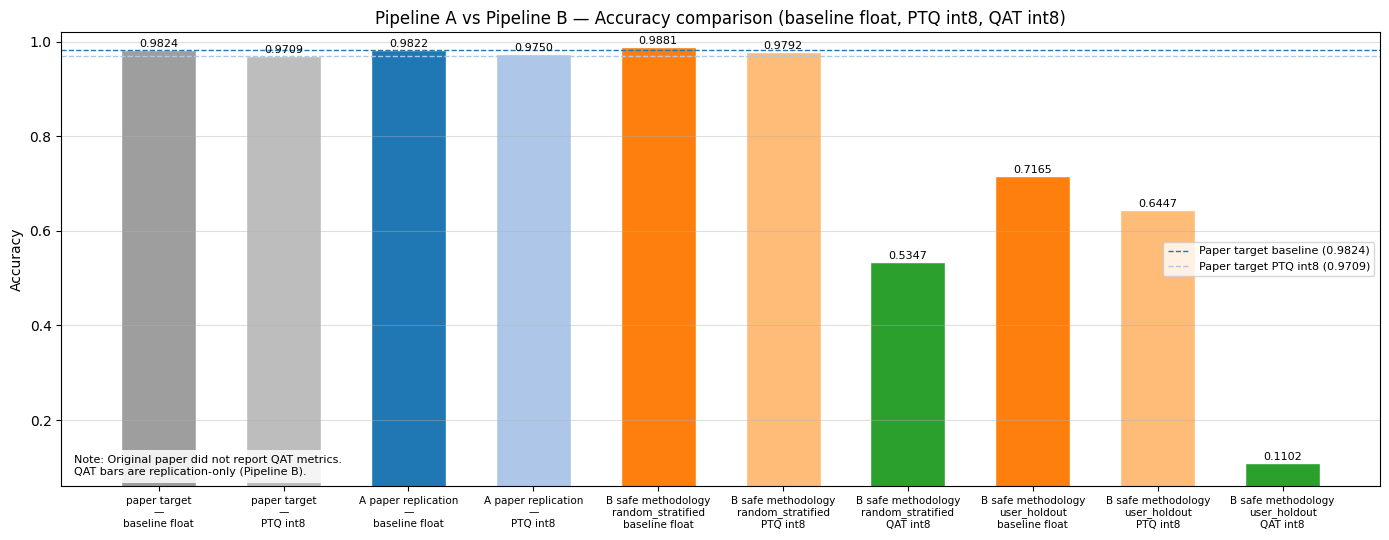

,pipeline,protocol,model,model_size_kb
0,paper target,—,PTQ int8,136.51 KB
1,A (paper replication),—,PTQ int8,136.93 KB
2,B (safe methodology),random_stratified,PTQ int8,136.92 KB
3,B (safe methodology),random_stratified,QAT int8,137.34 KB
4,B (safe methodology),user_holdout,PTQ int8,136.92 KB
5,B (safe methodology),user_holdout,QAT int8,137.34 KB



Reproducibility drift — Pipeline B (repeat evaluation on saved checkpoint):


/tmp/ipykernel_16080/418333693.py:214: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(repro_df[["protocol", "split_hash", "baseline_acc_first", "baseline_acc_repeat", "abs_drift", "status"]]


,protocol,split_hash,baseline_acc_first,baseline_acc_repeat,abs_drift,status
0,random_stratified,e8b3eefc294da8de,0.9881,0.9881,0.00e+00,PASS
1,user_holdout,8f23a2e13f210a67,0.7165,0.7165,0.00e+00,PASS



Note: Pipeline A has no drift check — split is not saved/hashed; results depend on library-version-specific random state.


In [20]:
# ── Build comparison rows ─────────────────────────────────────────────────────
_comp_rows = []

# Paper targets (reference)
_comp_rows.append({
    "pipeline": "paper target",
    "protocol": "—",
    "model": "baseline float",
    "accuracy": 0.9824,
    "macro_f1": None,
    "model_size_kb": None,
    "acc_delta_vs_A": None,
})
_comp_rows.append({
    "pipeline": "paper target",
    "protocol": "—",
    "model": "PTQ int8",
    "accuracy": 0.9709,
    "macro_f1": None,
    "model_size_kb": 136.51,
    "acc_delta_vs_A": None,
})
_comp_rows.append({
    "pipeline": "paper target",
    "protocol": "—",
    "model": "QAT int8",
    "accuracy": None,  # Not reported by the paper
    "macro_f1": None,
    "model_size_kb": None,
    "acc_delta_vs_A": None,
})

# Pipeline A
_comp_rows.append({
    "pipeline": "A (paper replication)",
    "protocol": "—",
    "model": "baseline float",
    "accuracy": round(float_accuracy_v2, 4),
    "macro_f1": None,  # weighted F1 in Pipeline A — incomparable to macro; omit
    "model_size_kb": None,
    "acc_delta_vs_A": 0.0,
})
_comp_rows.append({
    "pipeline": "A (paper replication)",
    "protocol": "—",
    "model": "PTQ int8",
    "accuracy": round(ptq_accuracy_v2, 4),
    "macro_f1": round(ptq_f1_v2, 4),
    "model_size_kb": round(model_size_v2_kb, 2),
    "acc_delta_vs_A": 0.0,
})
_comp_rows.append({
    "pipeline": "A (paper replication)",
    "protocol": "—",
    "model": "QAT int8",
    "accuracy": None,
    "macro_f1": None,
    "model_size_kb": None,
    "acc_delta_vs_A": None,
})

# Pipeline B
for _proto in PROTOCOLS:
    _bm = baseline_eval_metrics.get(_proto)
    if _bm:
        _b_acc = round(float(_bm["accuracy"]), 4)
        _comp_rows.append({
            "pipeline": "B (safe methodology)",
            "protocol": _proto,
            "model": "baseline float",
            "accuracy": _b_acc,
            "macro_f1": round(float(_bm["macro_f1"]), 4),
            "model_size_kb": None,
            "acc_delta_vs_A": round(_b_acc - float_accuracy_v2, 4),
        })

    _pm = ptq_eval_metrics.get(_proto)
    _pe = ptq_export_metrics.get(_proto)
    if _pm or _pe:
        _ptq_acc = round(float(_pm["accuracy"]), 4) if _pm else None
        _ptq_f1 = round(float(_pm["macro_f1"]), 4) if _pm else None
        _ptq_kb = (
            round(float(_pm["model_size_kb"]), 2)
            if _pm
            else (round(float(_pe["model_size_kb"]), 2) if _pe and _pe.get("model_size_kb") else None)
        )
        _comp_rows.append({
            "pipeline": "B (safe methodology)",
            "protocol": _proto,
            "model": "PTQ int8",
            "accuracy": _ptq_acc,
            "macro_f1": _ptq_f1,
            "model_size_kb": _ptq_kb,
            "acc_delta_vs_A": round(_ptq_acc - ptq_accuracy_v2, 4) if _ptq_acc is not None else None,
        })

    if RUN_QAT:
        _qm = qat_eval_metrics.get(_proto)
        _qe = qat_export_metrics.get(_proto)
        if _qm or _qe:
            _qat_acc = round(float(_qm["accuracy"]), 4) if _qm else None
            _qat_f1 = round(float(_qm["macro_f1"]), 4) if _qm else None
            _qat_kb = (
                round(float(_qm["model_size_kb"]), 2)
                if _qm
                else (round(float(_qe["model_size_kb"]), 2) if _qe and _qe.get("model_size_kb") else None)
            )
            _comp_rows.append({
                "pipeline": "B (safe methodology)",
                "protocol": _proto,
                "model": "QAT int8",
                "accuracy": _qat_acc,
                "macro_f1": _qat_f1,
                "model_size_kb": _qat_kb,
                "acc_delta_vs_A": None,  # Pipeline A has no QAT row to compare against
            })

comp_df = pd.DataFrame(_comp_rows).reset_index(drop=True)
display(comp_df.style
    .format({
        "accuracy": lambda v: f"{v:.4f}" if v is not None else "—",
        "macro_f1": lambda v: f"{v:.4f}" if v is not None else "—",
        "model_size_kb": lambda v: f"{v:.2f}" if v is not None else "—",
        "acc_delta_vs_A": lambda v: f"{v:+.4f}" if v is not None else "—",
    })
    .applymap(
        lambda v: "color: green" if isinstance(v, float) and v > 0 else (
            "color: red" if isinstance(v, float) and v < -0.0001 else ""
        ),
        subset=["acc_delta_vs_A"],
    )
    .set_caption("Table 1 — Accuracy, macro F1, model size, and accuracy delta vs Pipeline A (baseline/PTQ/QAT)")
)

print("Note: Original paper reports baseline and PTQ only; QAT results here are replication extensions.")

# ── Bar chart: accuracy by pipeline & model type ──────────────────────────────
_plot_rows = [r for r in _comp_rows if r["accuracy"] is not None]
_labels = [
    f"{r['pipeline'].replace('(', '').replace(')', '').strip()}\n{r['protocol']}\n{r['model']}"
    for r in _plot_rows
]
_accs = [r["accuracy"] for r in _plot_rows]

_colors = []
for r in _plot_rows:
    if r["pipeline"] == "paper target":
        if r["model"] == "baseline float":
            _colors.append("#9e9e9e")
        elif r["model"] == "PTQ int8":
            _colors.append("#bdbdbd")
        else:
            _colors.append("#d9d9d9")
    elif r["pipeline"].startswith("A"):
        if r["model"] == "baseline float":
            _colors.append("#1f77b4")
        elif r["model"] == "PTQ int8":
            _colors.append("#aec7e8")
        else:
            _colors.append("#9ecae1")
    else:
        if r["model"] == "baseline float":
            _colors.append("#ff7f0e")
        elif r["model"] == "PTQ int8":
            _colors.append("#ffbb78")
        elif r["model"] == "QAT int8":
            _colors.append("#2ca02c")
        else:
            _colors.append("#98df8a")

if _plot_rows:
    fig, ax = plt.subplots(figsize=(max(10, len(_plot_rows) * 1.4), 5.5))
    bars = ax.bar(_labels, _accs, color=_colors, edgecolor="white", width=0.6)
    ax.axhline(0.9824, color="#1f77b4", linestyle="--", linewidth=1.0, label="Paper target baseline (0.9824)")
    ax.axhline(0.9709, color="#aec7e8", linestyle="--", linewidth=1.0, label="Paper target PTQ int8 (0.9709)")
    for bar, acc in zip(bars, _accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{acc:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(max(0.0, min(_accs) - 0.05), 1.02)
    ax.set_ylabel("Accuracy")
    ax.set_title("Pipeline A vs Pipeline B — Accuracy comparison (baseline float, PTQ int8, QAT int8)")
    ax.text(
        0.01,
        0.02,
        "Note: Original paper did not report QAT metrics.\nQAT bars are replication-only (Pipeline B).",
        transform=ax.transAxes,
        fontsize=8,
        ha="left",
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    plt.xticks(fontsize=7.5)
    plt.tight_layout()
    plt.show()
else:
    print("(No accuracy rows available for comparison chart.)")

# ── Model size comparison (quantized models) ─────────────────────────────────
_size_rows = [r for r in _comp_rows if r["model"] in {"PTQ int8", "QAT int8"} and r["model_size_kb"] is not None]
if _size_rows:
    size_df = pd.DataFrame(
        [(r["pipeline"], r["protocol"], r["model"], r["model_size_kb"]) for r in _size_rows],
        columns=["pipeline", "protocol", "model", "model_size_kb"],
    )
    display(size_df.style
        .format({"model_size_kb": "{:.2f} KB"})
        .set_caption("Table 2 — Quantized model size (PTQ/QAT)")
    )

# ── Reproducibility drift (Pipeline B) ───────────────────────────────────────
print("\nReproducibility drift — Pipeline B (repeat evaluation on saved checkpoint):")
display(repro_df[["protocol", "split_hash", "baseline_acc_first", "baseline_acc_repeat", "abs_drift", "status"]]
    .style
    .format({
        "baseline_acc_first": "{:.4f}",
        "baseline_acc_repeat": "{:.4f}",
        "abs_drift": "{:.2e}",
    })
    .applymap(
        lambda v: "color: green" if v == "PASS" else "color: red",
        subset=["status"],
    )
    .set_caption("Table 3 — Reproducibility drift (Pipeline B, two consecutive evaluations)")
)
print("\nNote: Pipeline A has no drift check — split is not saved/hashed; "
      "results depend on library-version-specific random state.")


## Interpretation Notes and Limitations

### Pipeline A (Paper Replication)

Pipeline A deliberately reproduces the original notebook **flaws and all**. The goal is faithful
numeric replication, not a clean production pipeline.

| Flaw | Description |
|---|---|
| Global normalization | `StandardScaler` fit on the **entire dataset** before split. Test-set statistics leak into the scaler during fitting. |
| No validation set | 2-way split only. `x_test` is passed as `validation_data` in `model.fit`, so `EarlyStopping` and `ReduceLROnPlateau` make decisions based on the held-out test data. |
| Naive windowing | Sliding window over the full sorted DataFrame — windows can span two different users' recordings. |
| No split reproducibility | The original does not save or hash the split, making exact reproduction sensitive to library versions. |

### Pipeline B (Safe Methodology)

Pipeline B addresses all the above issues:
- Train-only `StandardScaler` (no data leakage)
- 3-way train / val / test split (dedicated validation for callbacks)
- Per-user windowing with `drop_cross_boundary` label policy
- `split_hash` saved for reproducibility
- `strict_deploy_status` is an integer I/O gate (`status=ok` and int8 input/output dtypes)

### QAT Status (Pipeline B)

Pipeline B keeps selective QAT annotation (`Conv2D` + `Dense`) for compatibility with
`tensorflow-model-optimization` `0.8.0` under TF 2.14.

In this project, deterministic GPU QAT can fail with `FakeQuantWithMinMaxVarsGradient`.
GPU failure followed by CPU retry has already been observed, and fallback support remains in the QAT cell.

For stable notebook reruns right now, defaults are CPU-only:
- `USE_GPU = False`
- `QAT_DEVICE_PREFERENCE = "cpu"`

The Grappler message `layout failed ... SelectV2-TransposeNHWCToNCHW-LayoutOptimizer` is
tracked as a non-fatal layout-optimization warning in this workflow.

### Suggested next steps
- Compare Pipeline A vs Pipeline B accuracy on `random_stratified` to quantify the effect of each methodological flaw.
- Run `RUN_MODE = "full"` for final replication logs.
- Re-run the QAT section and verify training curves for both protocols (`random_stratified`, `user_holdout`).
